<img src="connectx_intro_image.bmp" width="1400">

# Connect X - coding AI for competitive Games

## UNDER CONSTRUCTION

## Introduction

Kaggle hosts a competition to create an AI capable of winning at Connect X, a game similar to Connect 4.

You can find the full competition description, rules, and leaderboard on the Kaggle competition page:
https://www.kaggle.com/competitions/connectx

A common challenge in developing AI for discrete, turn-based games such as chess is determining how the AI should evaluate the best move. The natural instinct is to evaluate several moves ahead and then select the move that leads to the best future game state. While this intuition is correct, it overlooks several factors that make the problem more complex.

1. Simply choosing the best move from all possible future game states ignores the fact that the opponent is also playing optimally. A player cannot choose the future game state independently; the resulting state is determined by the combined decisions of both players.
 
2. The algorithm can rarely evaluate the entire game tree. Claude Shannon estimated that the lower bound for the number of possible chess games is approximately $10^{120}$, which is far too many to calculate exhaustively. Therefore, a search algorithm can only look ahead a limited number of moves. This search horizon is known as the search depth.

3. Evaluating whether one future state is better than another is not always straightforward. If a game state is a win or a loss, a large positive or negative score can be assigned to it. However, because the search cannot usually continue until the end of the game, the algorithm must eventually stop searching and estimate how favourable a non-terminal game state is without evaluating any further moves.

The term minimax is often used to describe the algorithm that performs this search. It accounts for the fact that both players are assumed to play optimally: one player chooses moves to maximize the evaluation score, while the other chooses moves to minimize it.

# Installing the Required Libraries

Before we begin, install the required libraries. In particular, the kaggle_environments package often needs to be installed before it can be imported.

In [1]:
import random
import time
from collections import defaultdict
import pandas as pd
from kaggle_environments import evaluate, make
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import time

Loading environment chess failed: No module named 'kaggle_environments.envs.chess.chess'
Loading environment llm_20_questions failed: No module named 'kaggle_environments.envs.llm_20_questions.llm_20_questions'
Loading environment lux_ai_s2 failed: No module named 'kaggle_environments.envs.lux_ai_s2.lux_ai_s2'
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 38.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_ant_foraging_arena
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_bargaining
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_python_ant_foraging
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_breakthrough
[kaggle_environments.envs.open_sp

18:47:59 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openrouter/deepseek/deepseek-v3.2-speciale not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info
18:47:59 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openrouter/qwen/qwen3-max not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info
18:47:59 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openrouter/z-ai/glm-4.5 not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info
18:47:59 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openrouter/z-ai/glm-4.5-air not in

Let us begin by submitting the suggested agent and seeing how well it performs.

In [2]:
def act_simple(observation, configuration):
    board = observation.board
    columns = configuration.columns
    return [c for c in range(columns) if board[c] == 0][0]

This agent always chooses the leftmost legal move. When submitted to the Kaggle competition, it achieves a low Elo rating of around 100. Let's see if we can improve upon this. We can also demo this agent against a random agent.

In [3]:
env = make("connectx", debug=True)
env.run([act_simple, "random"])
env.render(mode="ipython")

## Definitions

**Game state**: The current position of the pieces on the board. Specifically, the arrangement of all pieces that have been played in the Connect X board. This is sometimes refered to as "position."

**Agent**: The AI that is given the current game state as input and returns a suggested move. This is what we will submit to the Kaggle competition.

**Static evaluation**: An evaluation of how favourable a game state is without looking ahead to future moves. It returns a numerical score, where a positive value is good for the current player and a negative value is bad. It is typically based on a heuristic, such as the ratio of material each player has in chess. If the game state is a win or a loss, it is assigned a very large positive or negative score.

**Child position**: A possible future game state that can arise from a legal move made from the current game state.

**Search algorithm**: An algorithm that explores future child positions of a game state in order to maximise the static evaluation while accounting for the opponent's best possible responses.

## Building a Framework

Let's begin by defining the basic components needed to make different AIs compete in a tournament.

First, we will define a simple static evaluation function. Given a game state, if the current player has X pieces in a row, they have won and the function returns a score of 1000. If the opponent has X pieces in a row, it returns -1000. Otherwise, it returns 0.

This is a very simple evaluation function. We will develop more sophisticated evaluation functions later in the notebook.

In [4]:
def evaluate_board_static(
    board,
    mark,
    configuration=None,
    weights=None,
):
    """
    Basic static evaluation.

    configuration and weights are accepted so that this function
    has the same interface as the other evaluation functions.
    """
    opponent = 1 if mark == 2 else 2

    if winning_move(board, mark):
        return 10000

    if winning_move(board, opponent):
        return -1000

    return 0

Let us create some functions to update the board when a move is made. We will also define a function to determine whether a move results in a win.


In [5]:
ROWS = 6
COLUMNS = 7
INAROW = 4


def drop_piece(board, column, mark):
    """
    Return a new board after dropping a piece into a column.
    """
    new_board = board.copy()

    for row in range(ROWS - 1, -1, -1):
        index = row * COLUMNS + column

        if new_board[index] == 0:
            new_board[index] = mark
            return new_board

    return None


def winning_move(board, mark):
    """
    Return True if mark has four connected pieces.
    """

    # Horizontal
    for row in range(ROWS):
        for column in range(COLUMNS - 3):
            if all(
                board[row * COLUMNS + column + offset] == mark
                for offset in range(4)
            ):
                return True

    # Vertical
    for row in range(ROWS - 3):
        for column in range(COLUMNS):
            if all(
                board[(row + offset) * COLUMNS + column] == mark
                for offset in range(4)
            ):
                return True

    # Down-right diagonal
    for row in range(ROWS - 3):
        for column in range(COLUMNS - 3):
            if all(
                board[(row + offset) * COLUMNS + column + offset] == mark
                for offset in range(4)
            ):
                return True

    # Up-right diagonal
    for row in range(3, ROWS):
        for column in range(COLUMNS - 3):
            if all(
                board[(row - offset) * COLUMNS + column + offset] == mark
                for offset in range(4)
            ):
                return True

    return False


Let us ask an LLM to create functions that update the board when a move is made and determine whether that move results in a win.

In [6]:
def act_1stepwin(observation, configuration):
    """
    Look exactly one move ahead.

    If any legal move wins immediately, play it.
    Otherwise play the leftmost legal column.
    """

    board = observation.board
    mark = observation.mark

    valid_columns = [
        c
        for c in range(configuration.columns)
        if board[c] == 0
    ]

    for column in valid_columns:

        candidate = drop_piece(
            board,
            column,
            mark,
        )

        score = evaluate_board_static(
            candidate,
            mark,
        )

        if score == 10000:
            return column

    # No winning move found.
    return valid_columns[0]

We can also create a test function to check whether an agent returns valid moves.

In [7]:
def test_agents_can_move(agents):
    env = make("connectx", debug=True)
    observation = env.reset()[0].observation
    configuration = env.configuration

    for name, agent in agents:
        if isinstance(agent, str):
            print(f"{name}: built-in agent")
            continue

        try:
            move = agent(observation, configuration)
            print(f"{name}: returned column {move}")

        except Exception as error:
            print(
                f"{name}: FAILED — "
                f"{type(error).__name__}: {error}"
            )



We want to evaluate how strong different agents are against one another. We also want to measure how long each agent takes to select a move, as Kaggle enforces a maximum turn time of 2 seconds. If an agent exceeds this limit, it forfeits the game. Therefore, we will evaluate agents using two metrics: playing strength and speed.

One important consideration when evaluating agents is that they may be deterministic or non-deterministic. If two deterministic agents are repeatedly matched from the same starting position, they will play exactly the same game every time. To avoid this, we can initialise the board with a random opening of between 2 and 6 moves. This allows agents to compete from a variety of different positions, at the cost of introducing a small amount of noise into the evaluation.

We also record every move played and whether an agent throws an exception during a game. This provides an audit trail, allowing us to inspect games afterwards and sanity-check an agent's behaviour if unexpected results occur.

In [8]:

def evaluate_agents(
    agents,
    games_per_matchup=10,
    starting_seed=42,
    slow_move_threshold=2.0,
    print_progress=True,
    random_start=False,
):
    """
    Run a round-robin ConnectX tournament.

    Returns
    -------
    head_to_head_df : pandas.DataFrame
        Head-to-head score percentages.

    summary_df : pandas.DataFrame
        Overall results, error counts, and timing statistics.

        The Error column contains the agent name if that agent caused
        at least one game to end with an error. Otherwise, it is None.

    runtime_seconds : float
        Total tournament runtime.

    df_moves : pandas.DataFrame
        One row for every successfully recorded move in every game.
    """

    if len(agents) < 2:
        raise ValueError("At least two agents are required.")

    if games_per_matchup < 1:
        raise ValueError("games_per_matchup must be at least 1.")

    agent_names = [name for name, _ in agents]

    if len(agent_names) != len(set(agent_names)):
        raise ValueError("Every agent must have a unique name.")

    agent_lookup = dict(agents)
    number_of_agents = len(agent_names)

    total_matchups = (
        number_of_agents
        * (number_of_agents - 1)
        // 2
    )

    total_games_in_tournament = (
        total_matchups
        * games_per_matchup
    )

    score_matrix = pd.DataFrame(
        0.0,
        index=agent_names,
        columns=agent_names,
    )

    games_matrix = pd.DataFrame(
        0,
        index=agent_names,
        columns=agent_names,
        dtype=int,
    )

    results = {
        name: {
            "Games": 0,
            "Wins": 0,
            "Ties": 0,
            "Losses": 0,
        }
        for name in agent_names
    }

    move_times = defaultdict(list)
    slow_moves = defaultdict(int)

    # Number of games each agent caused to end with an error.
    error_counts = defaultdict(int)

    # Store the statuses encountered for each agent.
    error_statuses = defaultdict(list)

    # Each dictionary appended here becomes one row in df_moves.
    move_records = []

    def get_board(observation):
        """Return the board from either observation format."""
        if isinstance(observation, dict):
            return observation["board"]

        return observation.board

    def get_mark(observation):
        """Return the current player's mark."""
        if isinstance(observation, dict):
            return observation["mark"]

        return observation.mark

    def valid_moves(observation, configuration):
        """Return all legal columns."""
        board = get_board(observation)

        return [
            column
            for column in range(configuration.columns)
            if board[column] == 0
        ]

    def make_seeded_random_agent(seed):
        """Create a reproducible random agent."""
        rng = random.Random(seed)

        def random_agent(observation, configuration):
            moves = valid_moves(
                observation,
                configuration,
            )

            if not moves:
                return 0

            return rng.choice(moves)

        return random_agent

    def prepare_agent(agent, seed):
        """Convert an agent specification into a callable."""
        if isinstance(agent, str):
            if agent.lower() == "random":
                return make_seeded_random_agent(seed)

            raise ValueError(
                f"Unsupported built-in agent: {agent!r}"
            )

        if not callable(agent):
            raise TypeError(
                "Each agent must be callable or the string 'random'."
            )

        return agent

    def record_move(
        game_state,
        agent_name,
        observation,
        action,
        is_random_opening,
        elapsed_seconds,
    ):
        """Save one move to the tournament move history."""
        game_state["move_number"] += 1

        move_records.append({
            "Opponent 1": game_state["opponent_1"],
            "Opponent 2": game_state["opponent_2"],

            # Unique game number across the whole tournament.
            "Game Number":
                game_state["global_game_number"],

            # Game number within this particular matchup.
            "Matchup Game Number":
                game_state["matchup_game_number"],

            "Games Between Opponents":
                games_per_matchup,

            "Total Games in Tournament":
                total_games_in_tournament,

            "Move Number":
                game_state["move_number"],

            "Current Player":
                agent_name,

            "Player Mark":
                get_mark(observation),

            "Move":
                action,

            "Random Opening Move":
                is_random_opening,

            "Move Time Seconds":
                elapsed_seconds,
        })

    def make_game_agent(
        agent,
        agent_name,
        game_state,
    ):
        """
        Wrap an agent to:

        - make random opening moves when requested;
        - record every move;
        - time normal agent moves.
        """

        def game_agent(observation, configuration):

            # --------------------------------------------
            # Random opening phase
            # --------------------------------------------
            if game_state["opening_moves_remaining"] > 0:
                moves = valid_moves(
                    observation,
                    configuration,
                )

                if not moves:
                    return 0

                action = game_state[
                    "opening_rng"
                ].choice(moves)

                game_state[
                    "opening_moves_remaining"
                ] -= 1

                record_move(
                    game_state=game_state,
                    agent_name=agent_name,
                    observation=observation,
                    action=action,
                    is_random_opening=True,
                    elapsed_seconds=0.0,
                )

                return action

            # --------------------------------------------
            # Normal agent move
            # --------------------------------------------
            start = time.perf_counter()

            action = agent(
                observation,
                configuration,
            )

            elapsed = (
                time.perf_counter()
                - start
            )

            move_times[agent_name].append(
                elapsed
            )

            if elapsed > slow_move_threshold:
                slow_moves[agent_name] += 1

            record_move(
                game_state=game_state,
                agent_name=agent_name,
                observation=observation,
                action=action,
                is_random_opening=False,
                elapsed_seconds=elapsed,
            )

            return action

        game_agent.__name__ = agent_name
        return game_agent

    def play_game(
        first_name,
        second_name,
        first_seed,
        second_seed,
        global_game_number,
        matchup_game_number,
    ):
        """
        Play one game and record all its moves.

        Returns
        -------
        winner : str
            Winning agent name or "Tie".

        opening_moves : int
            Number of random opening moves used.

        error_player : str or None
            Name of the agent whose status was not "DONE".
            None when the game ended normally.

        error_status : str or None
            Kaggle environment status for the error player.
        """

        first_agent = prepare_agent(
            agent_lookup[first_name],
            first_seed,
        )

        second_agent = prepare_agent(
            agent_lookup[second_name],
            second_seed,
        )

        opening_seed = (
            first_seed * 31
            + second_seed * 17
            + 12345
        )

        opening_rng = random.Random(
            opening_seed
        )

        if random_start:
            opening_moves = opening_rng.choice(
                [2, 4, 6]
            )
        else:
            opening_moves = 0

        # Shared by both player wrappers.
        game_state = {
            "opponent_1":
                first_name,

            "opponent_2":
                second_name,

            "global_game_number":
                global_game_number,

            "matchup_game_number":
                matchup_game_number,

            "move_number":
                0,

            "opening_moves_remaining":
                opening_moves,

            "opening_rng":
                opening_rng,
        }

        wrapped_first = make_game_agent(
            agent=first_agent,
            agent_name=first_name,
            game_state=game_state,
        )

        wrapped_second = make_game_agent(
            agent=second_agent,
            agent_name=second_name,
            game_state=game_state,
        )

        env = make(
            "connectx",
            debug=False,
        )

        env.run([
            wrapped_first,
            wrapped_second,
        ])

        first_reward = env.state[0].reward
        second_reward = env.state[1].reward

        first_status = env.state[0].status
        second_status = env.state[1].status

        # A normal completed game gives both players
        # the status "DONE".
        error_player = None
        error_status = None

        if first_status != "DONE":
            error_player = first_name
            error_status = first_status

        elif second_status != "DONE":
            error_player = second_name
            error_status = second_status

        if first_reward == 1:
            winner = first_name

        elif second_reward == 1:
            winner = second_name

        else:
            winner = "Tie"

        return (
            winner,
            opening_moves,
            error_player,
            error_status,
        )

    tournament_start = time.perf_counter()

    matchup_number = 0
    global_game_number = 0

    for index_a in range(
        len(agent_names) - 1
    ):
        for index_b in range(
            index_a + 1,
            len(agent_names),
        ):
            matchup_number += 1

            agent_a = agent_names[index_a]
            agent_b = agent_names[index_b]

            if print_progress:
                print(
                    f"\n{agent_a} versus {agent_b}"
                )

            for game_index in range(
                games_per_matchup
            ):
                global_game_number += 1

                matchup_game_number = (
                    game_index + 1
                )

                # Alternate who starts.
                if game_index % 2 == 0:
                    first_name = agent_a
                    second_name = agent_b
                else:
                    first_name = agent_b
                    second_name = agent_a

                game_seed = (
                    starting_seed
                    + matchup_number * 100_000
                    + game_index * 2
                )

                (
                    winner,
                    opening_moves,
                    error_player,
                    error_status,
                ) = play_game(
                    first_name=first_name,
                    second_name=second_name,
                    first_seed=game_seed,
                    second_seed=game_seed + 1,
                    global_game_number=
                        global_game_number,
                    matchup_game_number=
                        matchup_game_number,
                )

                # Record the player responsible for an
                # abnormal game termination.
                if error_player is not None:
                    error_counts[
                        error_player
                    ] += 1

                    error_statuses[
                        error_player
                    ].append(
                        error_status
                    )

                games_matrix.loc[
                    agent_a,
                    agent_b,
                ] += 1

                games_matrix.loc[
                    agent_b,
                    agent_a,
                ] += 1

                results[agent_a]["Games"] += 1
                results[agent_b]["Games"] += 1

                if winner == "Tie":
                    results[agent_a]["Ties"] += 1
                    results[agent_b]["Ties"] += 1

                    score_matrix.loc[
                        agent_a,
                        agent_b,
                    ] += 0.5

                    score_matrix.loc[
                        agent_b,
                        agent_a,
                    ] += 0.5

                    result_text = "Tie"

                elif winner == agent_a:
                    results[agent_a]["Wins"] += 1
                    results[agent_b]["Losses"] += 1

                    score_matrix.loc[
                        agent_a,
                        agent_b,
                    ] += 1.0

                    result_text = (
                        f"{agent_a} wins"
                    )

                else:
                    results[agent_b]["Wins"] += 1
                    results[agent_a]["Losses"] += 1

                    score_matrix.loc[
                        agent_b,
                        agent_a,
                    ] += 1.0

                    result_text = (
                        f"{agent_b} wins"
                    )

                if print_progress:
                    if random_start:
                        opening_text = (
                            f", random opening: "
                            f"{opening_moves} moves"
                        )
                    else:
                        opening_text = ""

                    if error_player is not None:
                        error_text = (
                            f", error: {error_player} "
                            f"({error_status})"
                        )
                    else:
                        error_text = ""

                    print(
                        f"  Tournament game "
                        f"{global_game_number}/"
                        f"{total_games_in_tournament}: "
                        f"{result_text} "
                        f"(started: {first_name}"
                        f"{opening_text}"
                        f"{error_text})"
                    )

    runtime_seconds = (
        time.perf_counter()
        - tournament_start
    )

    # Convert points to head-to-head percentages.
    head_to_head_df = (
        score_matrix
        .div(
            games_matrix.where(
                games_matrix != 0
            )
        )
        .mul(100)
    )

    head_to_head_df.index.name = "Agent"

    summary_rows = []

    for name in agent_names:
        games = results[name]["Games"]
        wins = results[name]["Wins"]
        ties = results[name]["Ties"]
        losses = results[name]["Losses"]

        times = move_times[name]
        moves_timed = len(times)

        average_time = (
            sum(times) / moves_timed
            if moves_timed
            else 0.0
        )

        summary_rows.append({
            "Agent":
                name,

            "Games":
                games,

            "Wins":
                wins,

            "Ties":
                ties,

            "Losses":
                losses,

            # Agent name when it caused at least one
            # error; otherwise None.
            "Error": (
                name
                if error_counts[name] > 0
                else None
            ),

            "Error Count":
                error_counts[name],

            # Shows all distinct error statuses, for
            # example "ERROR", "INVALID" or "TIMEOUT".
            "Error Status": (
                ", ".join(
                    sorted(
                        set(error_statuses[name])
                    )
                )
                if error_statuses[name]
                else None
            ),

            "Win Rate": (
                wins / games
                if games
                else 0.0
            ),

            "Tie Rate": (
                ties / games
                if games
                else 0.0
            ),

            "Loss Rate": (
                losses / games
                if games
                else 0.0
            ),

            "Score Rate": (
                (wins + 0.5 * ties) / games
                if games
                else 0.0
            ),

            "Moves Timed":
                moves_timed,

            "Average Seconds Per Move":
                average_time,

            "Moves Over 2 Seconds":
                slow_moves[name],

            "Slow Move Rate": (
                slow_moves[name] / moves_timed
                if moves_timed
                else 0.0
            ),
        })

    summary_df = (
        pd.DataFrame(summary_rows)
        .set_index("Agent")
    )

    df_moves = pd.DataFrame(
        move_records
    )

    print(
        f"\nTotal tournament time: "
        f"{runtime_seconds:.2f} seconds"
    )

    return (
        head_to_head_df,
        summary_df,
        runtime_seconds,
        df_moves,
    )

Let us take the results from this round-robin tournament and plot them to help visualise how well each agent is performing.

In [9]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_agent_results(
    summary_df,
    head_to_head_df=None,
):
    """
    Plot tournament performance, runtime, and failure statistics.

    Parameters
    ----------
    summary_df:
        Agent-level summary returned by evaluate_agents().

        Expected columns include:
            Wins
            Ties
            Losses
            Score Rate
            Average Seconds Per Move
            Error Count

    head_to_head_df:
        Optional head-to-head percentage dataframe.
    """
    if summary_df.empty:
        print("No agent results are available to plot.")
        return

    plot_df = summary_df.copy()

    numeric_columns = [
        "Wins",
        "Ties",
        "Losses",
        "Score Rate",
        "Average Seconds Per Move",
        "Error Count",
    ]

    for column in numeric_columns:
        if column in plot_df.columns:
            plot_df[column] = pd.to_numeric(
                plot_df[column],
                errors="coerce",
            ).fillna(0)

    # ============================================================
    # 1. Wins, ties, and losses
    # ============================================================
    required_result_columns = {
        "Wins",
        "Ties",
        "Losses",
    }

    if required_result_columns.issubset(
        plot_df.columns
    ):
        result_data = plot_df[
            ["Wins", "Ties", "Losses"]
        ]

        axis = result_data.plot(
            kind="bar",
            stacked=True,
            figsize=(12, 6),
        )

        axis.set_title(
            "Tournament results by agent"
        )
        axis.set_xlabel("Agent")
        axis.set_ylabel("Games")
        axis.legend(title="Result")
        axis.tick_params(
            axis="x",
            rotation=45,
        )

        plt.tight_layout()
        plt.show()

    # ============================================================
    # 2. Score rate
    # ============================================================
    if "Score Rate" in plot_df.columns:
        score_data = (
            plot_df["Score Rate"]
            .sort_values(
                ascending=False
            )
            .mul(100)
        )

        axis = score_data.plot(
            kind="bar",
            figsize=(12, 6),
        )

        axis.set_title(
            "Agent score rate"
        )
        axis.set_xlabel("Agent")
        axis.set_ylabel("Score rate (%)")
        axis.tick_params(
            axis="x",
            rotation=45,
        )

        maximum_score = (
            score_data.max()
            if not score_data.empty
            else 0
        )

        axis.set_ylim(
            0,
            max(
                100,
                maximum_score * 1.1,
            ),
        )

        for position, value in enumerate(
            score_data
        ):
            axis.text(
                position,
                value,
                f"{value:.1f}%",
                ha="center",
                va="bottom",
            )

        plt.tight_layout()
        plt.show()

    # ============================================================
    # 3. Average move time
    # ============================================================
    if (
        "Average Seconds Per Move"
        in plot_df.columns
    ):
        time_data = (
            plot_df[
                "Average Seconds Per Move"
            ]
            .sort_values(
                ascending=False
            )
        )

        axis = time_data.plot(
            kind="bar",
            figsize=(12, 6),
        )

        axis.set_title(
            "Average move time by agent"
        )
        axis.set_xlabel("Agent")
        axis.set_ylabel(
            "Average seconds per move"
        )
        axis.tick_params(
            axis="x",
            rotation=45,
        )

        for position, value in enumerate(
            time_data
        ):
            axis.text(
                position,
                value,
                f"{value:.3f}",
                ha="center",
                va="bottom",
            )

        plt.tight_layout()
        plt.show()

    # ============================================================
    # 4. Failed games by agent
    # ============================================================
    if "Error Count" in plot_df.columns:
        failure_data = (
            plot_df["Error Count"]
            .fillna(0)
            .astype(int)
            .sort_values(
                ascending=False
            )
        )

    # Compatibility with an older column name.
    elif "Error Games" in plot_df.columns:
        failure_data = (
            pd.to_numeric(
                plot_df["Error Games"],
                errors="coerce",
            )
            .fillna(0)
            .astype(int)
            .sort_values(
                ascending=False
            )
        )

    # This fallback can only show whether an error occurred,
    # not the number of errors.
    elif "Error" in plot_df.columns:
        failure_data = (
            plot_df["Error"]
            .notna()
            .astype(int)
            .sort_values(
                ascending=False
            )
        )

        print(
            "Warning: summary_df has no 'Error Count' column. "
            "The error plot can only show 0 or 1 per agent."
        )

    else:
        failure_data = pd.Series(
            0,
            index=plot_df.index,
            dtype=int,
        )

    axis = failure_data.plot(
        kind="bar",
        figsize=(12, 6),
    )

    axis.set_title(
        "Failed games by agent"
    )
    axis.set_xlabel("Agent")
    axis.set_ylabel("Failed games")
    axis.tick_params(
        axis="x",
        rotation=45,
    )

    maximum_failures = (
        int(failure_data.max())
        if not failure_data.empty
        else 0
    )

    axis.set_ylim(
        0,
        max(
            1,
            maximum_failures + 1,
        ),
    )

    axis.yaxis.set_major_locator(
        plt.MaxNLocator(integer=True)
    )

    for position, value in enumerate(
        failure_data
    ):
        axis.text(
            position,
            value,
            str(int(value)),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    # ============================================================
    # 5. Optional head-to-head matrix
    # ============================================================
    if (
        head_to_head_df is not None
        and not head_to_head_df.empty
    ):
        heatmap_df = head_to_head_df.apply(
            pd.to_numeric,
            errors="coerce",
        )

        heatmap_values = (
            heatmap_df
            .fillna(0)
            .to_numpy(dtype=float)
        )

        figure, axis = plt.subplots(
            figsize=(10, 8)
        )

        image = axis.imshow(
            heatmap_values,
            aspect="auto",
        )

        axis.set_title(
            "Head-to-head score percentage"
        )

        axis.set_xticks(
            range(len(heatmap_df.columns))
        )

        axis.set_xticklabels(
            heatmap_df.columns,
            rotation=45,
            ha="right",
        )

        axis.set_yticks(
            range(len(heatmap_df.index))
        )

        axis.set_yticklabels(
            heatmap_df.index
        )

        for row_index in range(
            len(heatmap_df.index)
        ):
            for column_index in range(
                len(heatmap_df.columns)
            ):
                value = heatmap_df.iloc[
                    row_index,
                    column_index,
                ]

                if pd.notna(value):
                    label = f"{value:.0f}%"
                else:
                    label = "—"

                axis.text(
                    column_index,
                    row_index,
                    label,
                    ha="center",
                    va="center",
                )

        figure.colorbar(
            image,
            ax=axis,
            label="Score percentage",
        )

        plt.tight_layout()
        plt.show()

Let us also introduce a function that accepts the game arrays returned by our evaluate_agents function and displays a game in an intuitive, easy-to-read format.

In [10]:
def show_game_moves(
    df_moves,
    game_number,
    rows=6,
    columns=7,
):
    """
    Display one saved game and print the board after every move.

    Parameters
    ----------
    df_moves : pandas.DataFrame
        Move history returned by evaluate_agents().

    game_number : int
        Global tournament game number to display.

    rows : int
        Number of ConnectX rows.

    columns : int
        Number of ConnectX columns.
    """

    required_columns = {
        "Opponent 1",
        "Opponent 2",
        "Game Number",
        "Move Number",
        "Current Player",
        "Player Mark",
        "Move",
    }

    missing = required_columns.difference(
        df_moves.columns
    )

    if missing:
        raise ValueError(
            "df_moves is missing: "
            + ", ".join(sorted(missing))
        )

    game_df = (
        df_moves[
            df_moves["Game Number"]
            == game_number
        ]
        .copy()
        .sort_values("Move Number")
        .reset_index(drop=True)
    )

    if game_df.empty:
        raise ValueError(
            f"Game {game_number} was not found."
        )

    opponent_1 = game_df.loc[
        0,
        "Opponent 1",
    ]

    opponent_2 = game_df.loc[
        0,
        "Opponent 2",
    ]

    print("=" * 70)
    print(f"GAME {game_number}")
    print(
        f"Player 1 (X): {opponent_1}"
    )
    print(
        f"Player 2 (O): {opponent_2}"
    )
    print("=" * 70)

    print("\nMOVE DATA")
    print(game_df.to_string(index=False))

    board = [0] * (rows * columns)

    symbols = {
        0: ".",
        1: "X",
        2: "O",
    }

    def place_piece(board, column, mark):
        """Place a piece using ConnectX gravity."""
        if not 0 <= column < columns:
            raise ValueError(
                f"Invalid column: {column}"
            )

        for row in range(rows - 1, -1, -1):
            index = row * columns + column

            if board[index] == 0:
                board[index] = mark
                return

        raise ValueError(
            f"Column {column} is full."
        )

    def print_board(board):
        """Print the current board."""
        print(
            "  "
            + " ".join(
                str(column)
                for column in range(columns)
            )
        )

        for row in range(rows):
            row_symbols = [
                symbols[
                    board[
                        row * columns + column
                    ]
                ]
                for column in range(columns)
            ]

            print(
                "| "
                + " ".join(row_symbols)
                + " |"
            )

        print(
            "+"
            + "--" * columns
            + "+"
        )

    print("\nINITIAL BOARD")
    print_board(board)

    for _, move_row in game_df.iterrows():
        move_number = int(
            move_row["Move Number"]
        )

        player_name = move_row[
            "Current Player"
        ]

        mark = int(
            move_row["Player Mark"]
        )

        column = int(
            move_row["Move"]
        )

        place_piece(
            board,
            column,
            mark,
        )

        random_opening = move_row.get(
            "Random Opening Move",
            False,
        )

        if bool(random_opening):
            move_type = "random opening"
        else:
            move_type = "agent move"

        print(
            f"\nMove {move_number}: "
            f"{player_name} "
            f"played column {column} "
            f"({move_type})"
        )

        print_board(board)

    return game_df

Now we can define two agents for the tournament. One is the random agent provided by Kaggle, and the other is the act_1stepwin agent that we have just defined.

In [11]:
agents = [
    ("Random", "random"),
    ("OneStepWin", act_1stepwin)
]

Now we can define two agents for the tournament. The first is the random agent provided by Kaggle, and the second is the act_1stepwin agent that we just defined.

In [12]:
head_to_head_df, summary_df, runtime_seconds, df_moves = evaluate_agents(
    agents=agents,
    games_per_matchup=40,
    starting_seed=42,
)


Random versus OneStepWin
  Tournament game 1/40: OneStepWin wins (started: Random)
  Tournament game 2/40: OneStepWin wins (started: OneStepWin)
  Tournament game 3/40: Random wins (started: Random)
  Tournament game 4/40: OneStepWin wins (started: OneStepWin)
  Tournament game 5/40: OneStepWin wins (started: Random)
  Tournament game 6/40: OneStepWin wins (started: OneStepWin)
  Tournament game 7/40: Random wins (started: Random)
  Tournament game 8/40: OneStepWin wins (started: OneStepWin)
  Tournament game 9/40: Random wins (started: Random)
  Tournament game 10/40: OneStepWin wins (started: OneStepWin)
  Tournament game 11/40: OneStepWin wins (started: Random)
  Tournament game 12/40: OneStepWin wins (started: OneStepWin)
  Tournament game 13/40: OneStepWin wins (started: Random)
  Tournament game 14/40: OneStepWin wins (started: OneStepWin)
  Tournament game 15/40: OneStepWin wins (started: Random)
  Tournament game 16/40: OneStepWin wins (started: OneStepWin)
  Tournament game 1

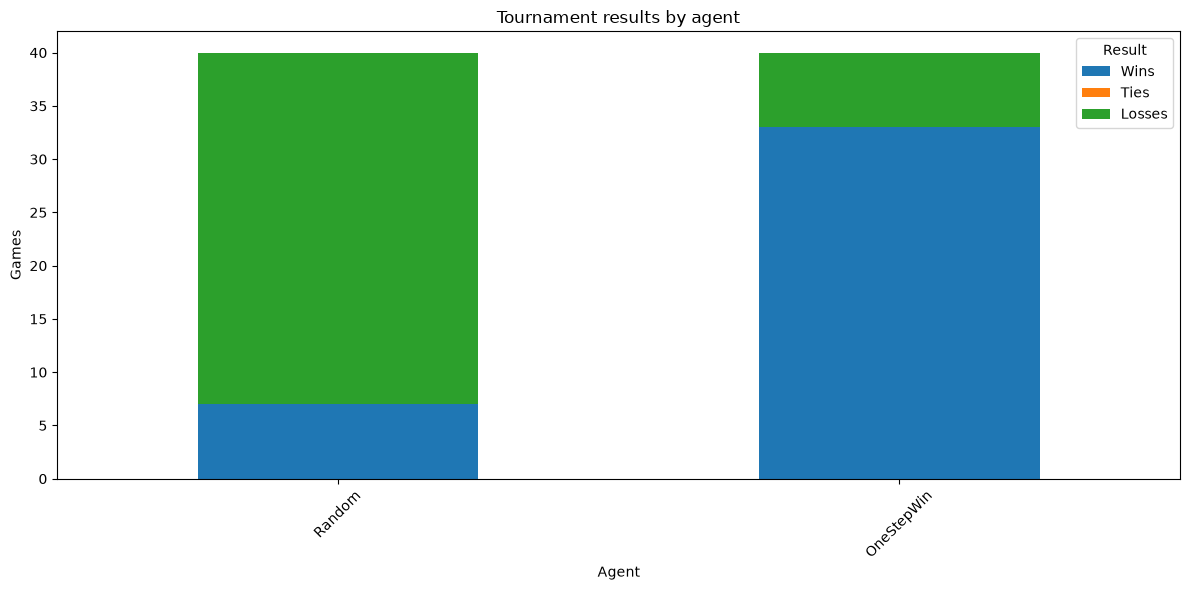

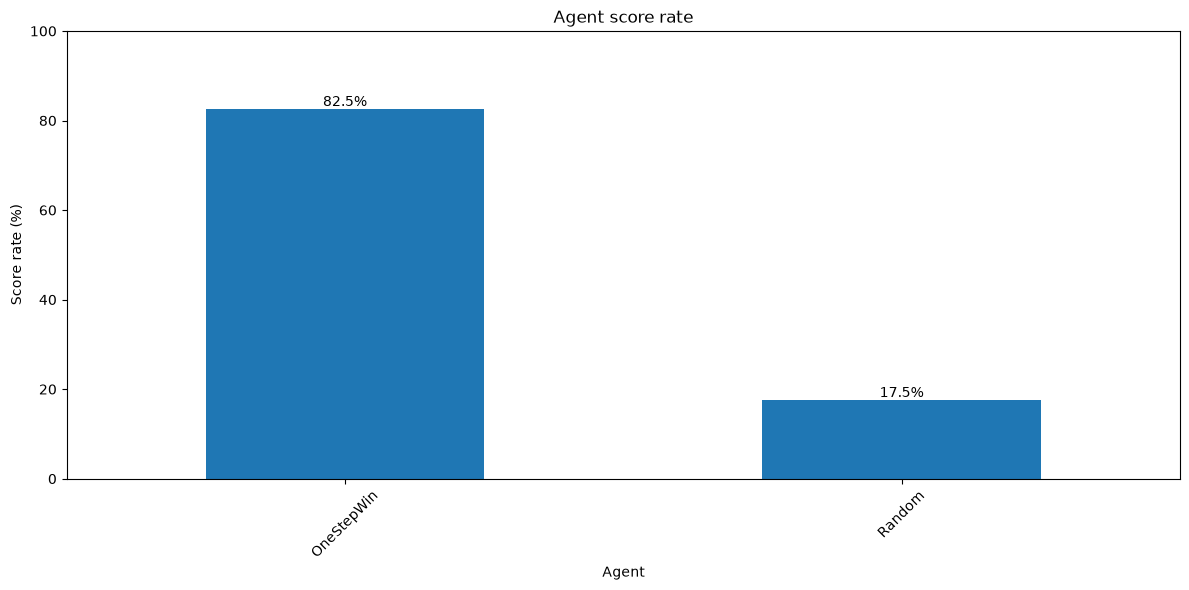

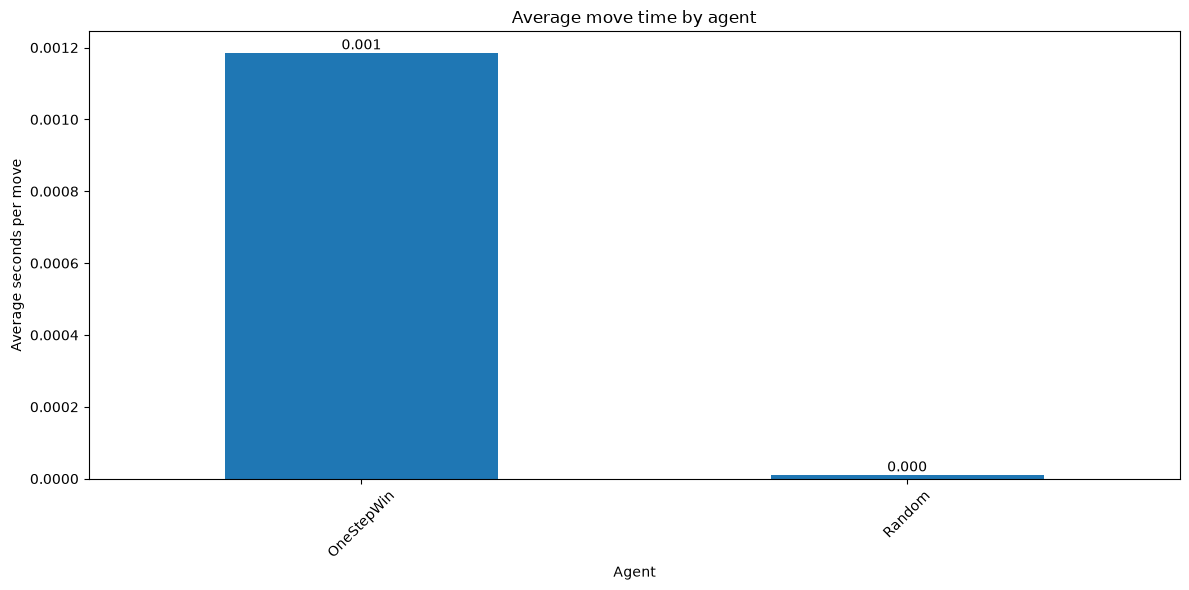

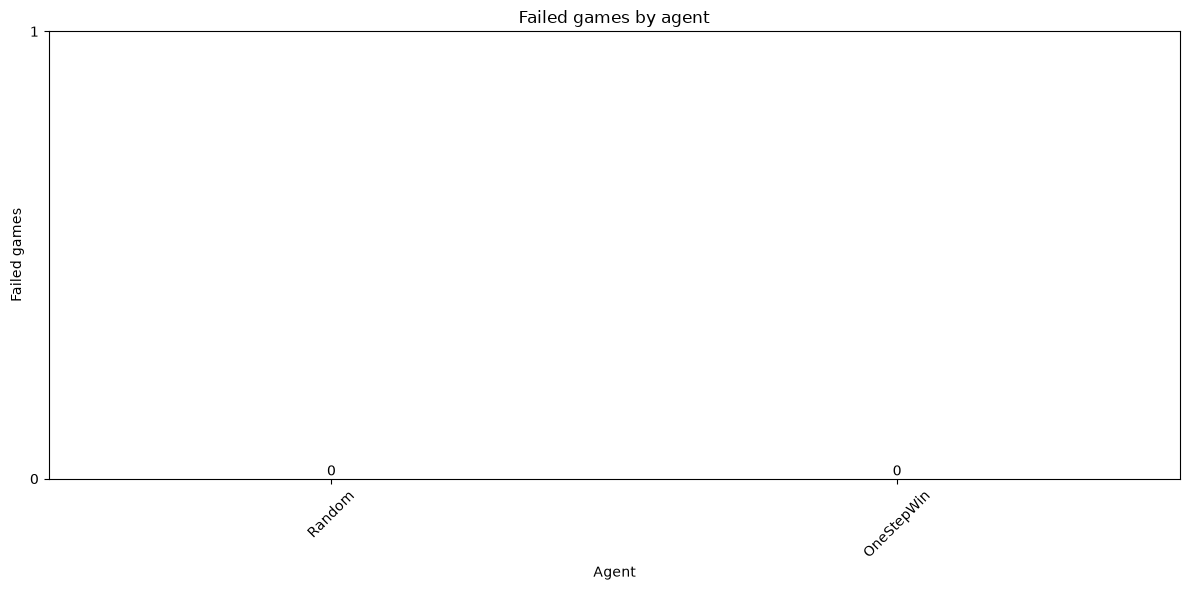

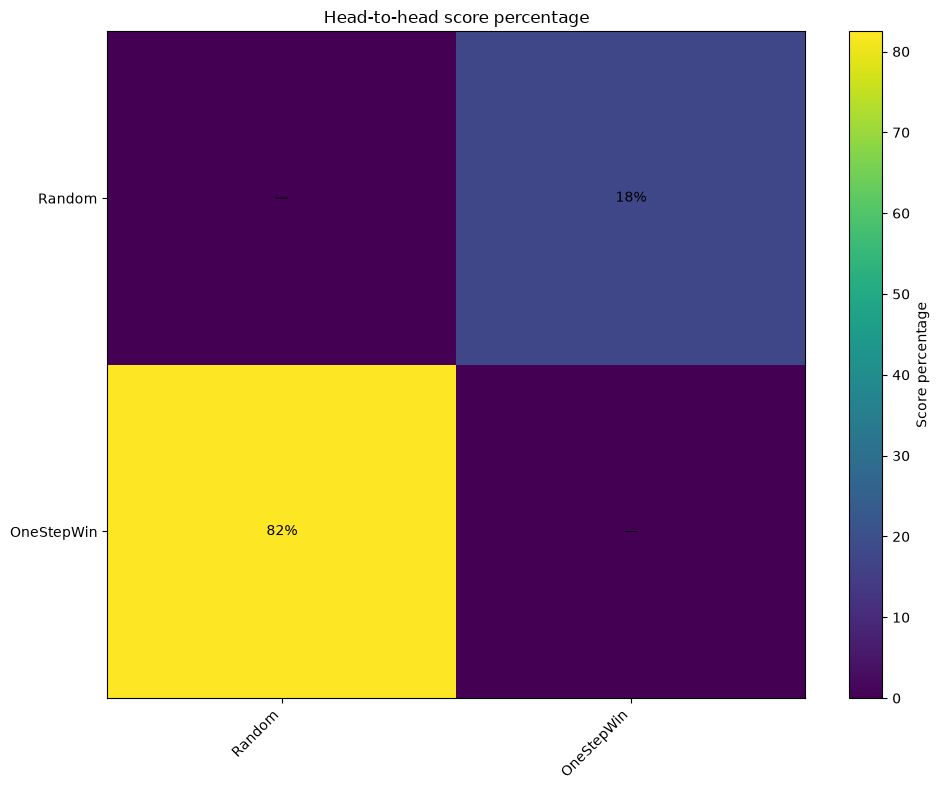

In [13]:
plot_agent_results(
    summary_df,
    head_to_head_df,
)

We see a basic agent looking forward one step does a lot better than a random agent as we might expect, but takes slightly more time to decide its move. 


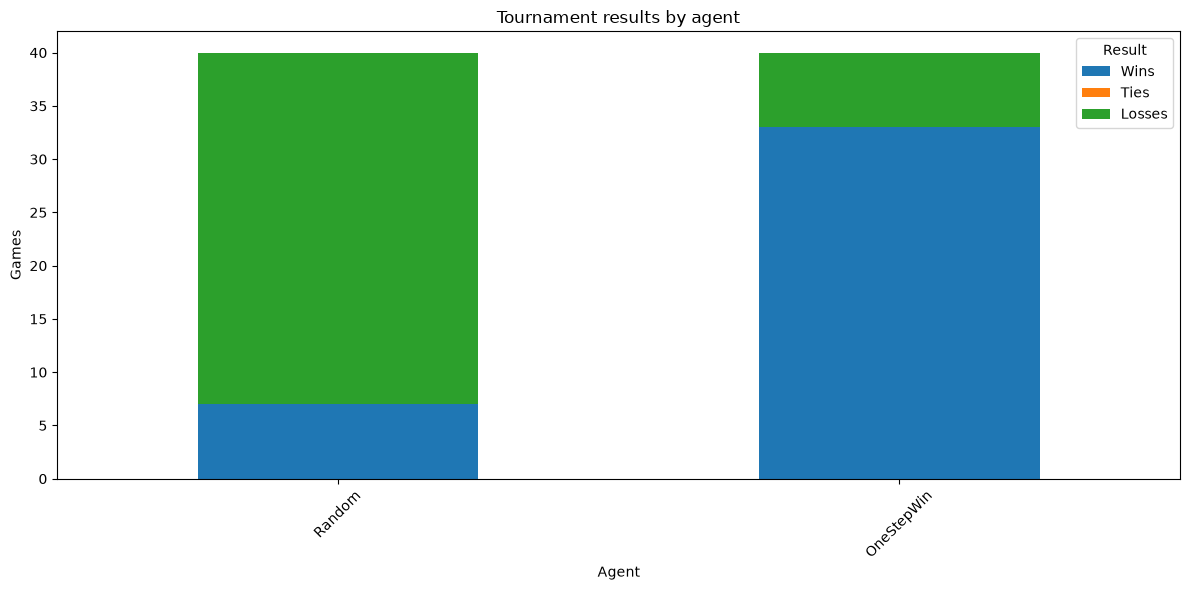

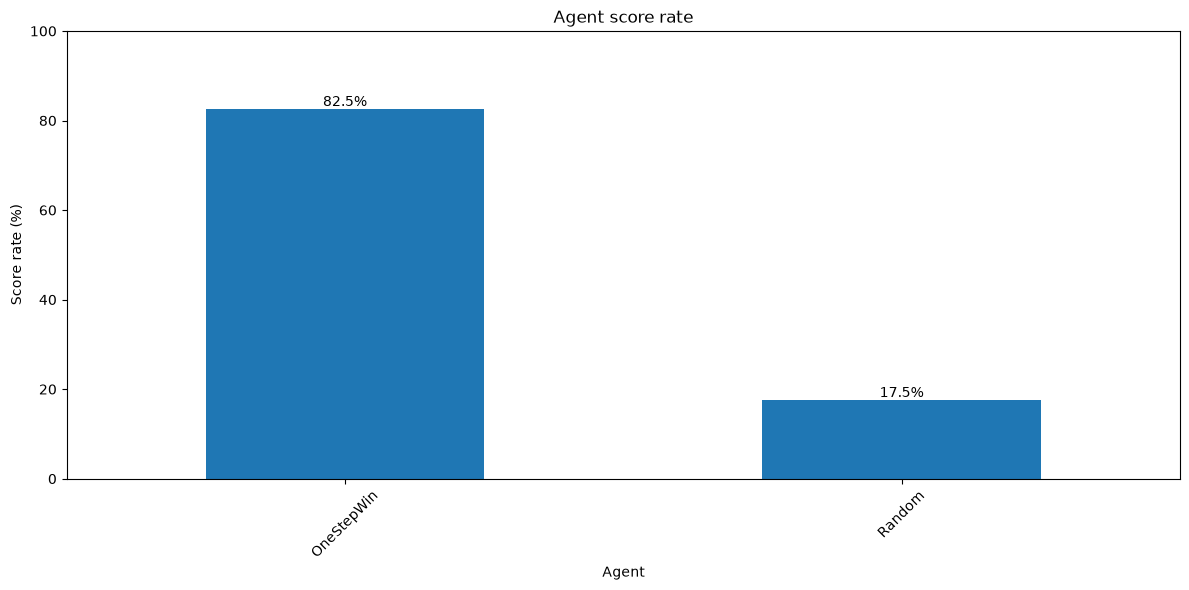

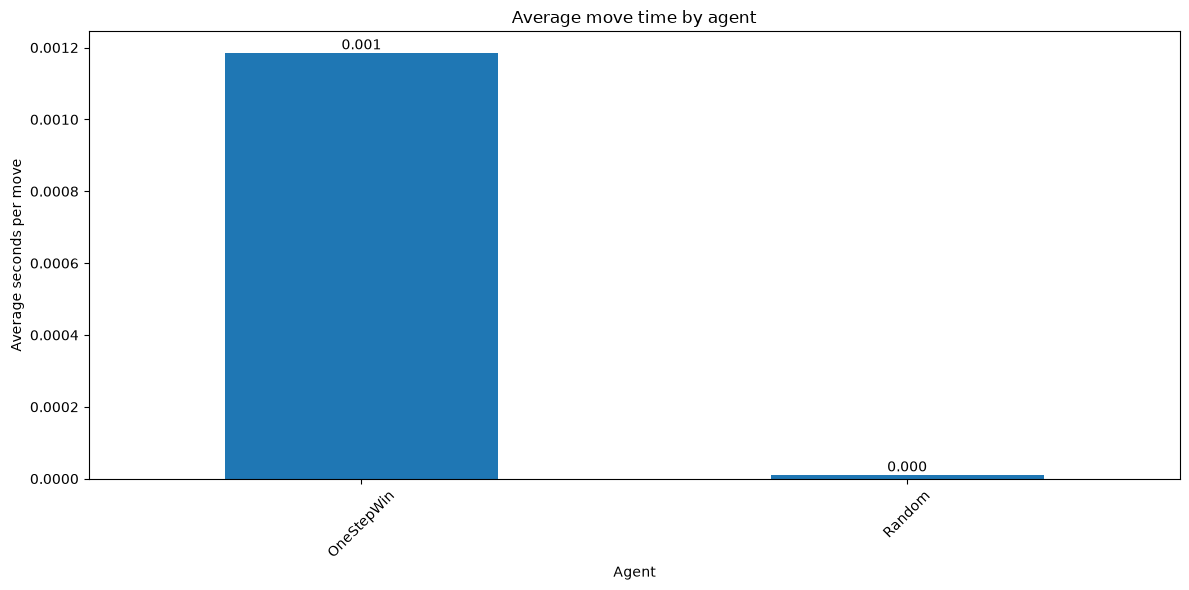

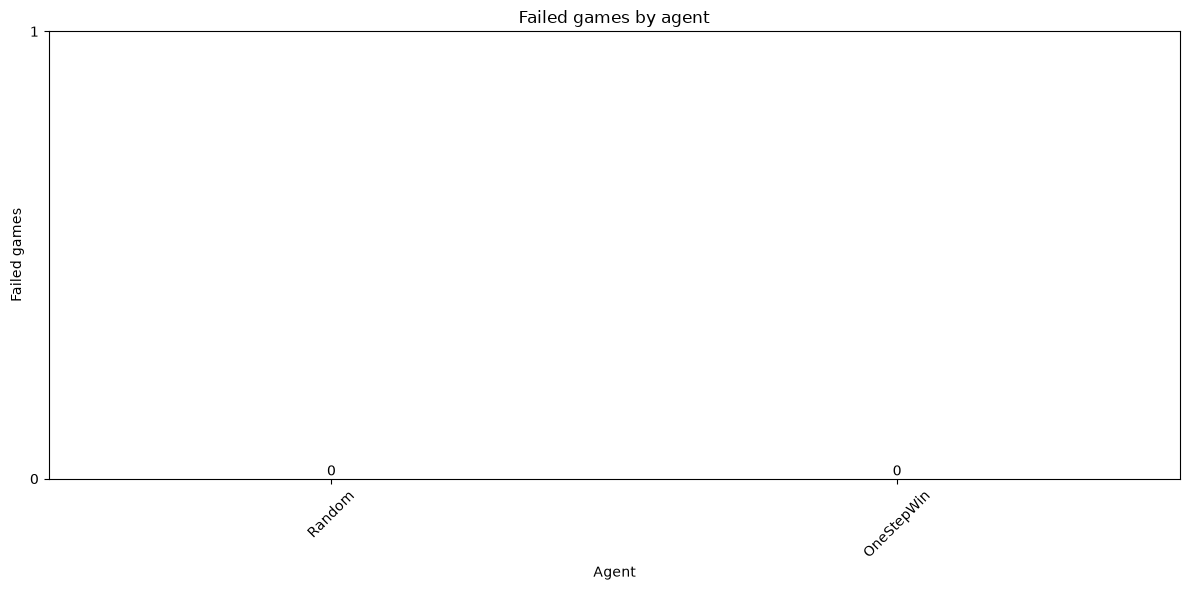

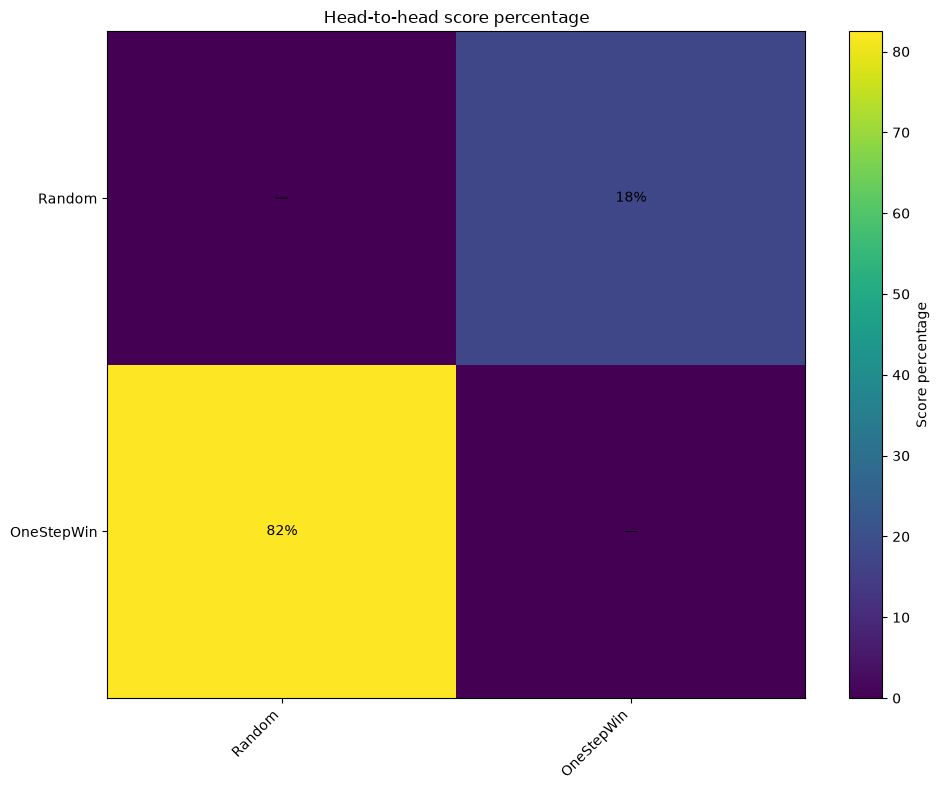

In [14]:
plot_agent_results(
    summary_df,
    head_to_head_df,
)

Let us review a typical game.

In [15]:
show_game_moves(
    df_moves,
    game_number=8,
)

GAME 8
Player 1 (X): OneStepWin
Player 2 (O): Random

MOVE DATA
Opponent 1 Opponent 2  Game Number  Matchup Game Number  Games Between Opponents  Total Games in Tournament  Move Number Current Player  Player Mark  Move  Random Opening Move  Move Time Seconds
OneStepWin     Random            8                    8                       40                         40            1     OneStepWin            1     0                False           0.001926
OneStepWin     Random            8                    8                       40                         40            2         Random            2     6                False           0.000011
OneStepWin     Random            8                    8                       40                         40            3     OneStepWin            1     0                False           0.001488
OneStepWin     Random            8                    8                       40                         40            4         Random            2     6  

,Opponent 1,Opponent 2,Game Number,Matchup Game Number,Games Between Opponents,Total Games in Tournament,Move Number,Current Player,Player Mark,Move,Random Opening Move,Move Time Seconds
0,OneStepWin,Random,8,8,40,40,1,OneStepWin,1,0,False,0.001926
1,OneStepWin,Random,8,8,40,40,2,Random,2,6,False,0.000011
2,OneStepWin,Random,8,8,40,40,3,OneStepWin,1,0,False,0.001488
3,OneStepWin,Random,8,8,40,40,4,Random,2,6,False,0.000011
4,OneStepWin,Random,8,8,40,40,5,OneStepWin,1,0,False,0.001188
5,OneStepWin,Random,8,8,40,40,6,Random,2,4,False,0.000007
6,OneStepWin,Random,8,8,40,40,7,OneStepWin,1,0,False,0.000055


## Minimax Function

Now let us create a proper minimax function to evaluate future game states. We will use alpha-beta pruning to reduce the amount of unnecessary computation. A brief explanation is provided below.

Without alpha-beta pruning, the minimax algorithm evaluates every possible child position and every subsequent descendant up to a specified search depth. At each level, the current player selects the move with the highest evaluation score, while the opponent selects the move with the lowest score.

This is analogous to a sequence of moves in which both players act in their own best interests, assuming that one player aims to maximise the static evaluation score and the other aims to minimise it.

The algorithm must therefore explore every child and grandchild position within the search depth. The diagram below shows an example of what this game tree might look like. The blue lines represent the moves that each player is expected to choose when optimising the static evaluation function.

<img src="search_ab_tree1.bmp" width="1400">

## Alpha-Beta Pruning

Alpha-beta pruning recognises that not every child position needs to be evaluated.

Suppose one child at the first level has already been evaluated and produces a score of **alpha**. When exploring another branch, if the opponent can force a score lower than alpha, there is no need to continue evaluating that branch. This is because the current player already has an alternative that guarantees a score of at least alpha and would therefore never choose the inferior branch.

By discarding branches that cannot affect the final decision, alpha-beta pruning can significantly reduce the number of positions that must be evaluated while still producing the same result as a full minimax search.

The flow diagram below illustrates how alpha-beta pruning works and shows how it can reduce the amount of computation required in our example.


<img src="search_ab_prune.bmp" width="1400">

<img src="search_ab_tree2.bmp" width="1400">

Let us ask an LLM to write a standard alpha-beta pruning function. We want to make the implementation flexible enough to support multiple agents.

The function should accept the **search depth** as a parameter so that different agents can be configured to look ahead by different numbers of moves. It should also accept the **evaluation function** that the minimax search will maximise or minimise.

Because some evaluation functions may require additional weighting parameters, the implementation should allow these values to be passed in as well. By supplying the search depth, evaluation function, and any associated weights, we can reuse the same alpha-beta pruning function across a range of different agents.


In [16]:
# ============================================================
# SHARED ALPHA-BETA FUNCTIONS
# ============================================================

def get_valid_columns(board, configuration):
    """Return all legal columns."""
    return [
        column
        for column in range(configuration.columns)
        if board[column] == 0
    ]


def alphabeta_search(
    board,
    depth,
    alpha,
    beta,
    maximizing_player,
    agent_mark,
    configuration,
    evaluation_function,
    evaluation_weights=None,
):
    """
    Recursive minimax search with alpha-beta pruning.
    """
    opponent_mark = 1 if agent_mark == 2 else 2

    valid_columns = get_valid_columns(
        board,
        configuration,
    )

    # Terminal states
    if winning_move(board, agent_mark):
        return 10000 + depth

    if winning_move(board, opponent_mark):
        return -10000 - depth

    if not valid_columns:
        return 0

    # Search limit reached
    if depth == 0:
        return evaluation_function(
            board=board,
            mark=agent_mark,
            configuration=configuration,
            weights=evaluation_weights,
        )

    ordered_columns = sorted(
        valid_columns,
        key=lambda column: (
            abs(
                column
                - configuration.columns // 2
            ),
            column,
        ),
    )

    if maximizing_player:
        best_score = -float("inf")

        for column in ordered_columns:
            child_board = drop_piece(
                board,
                column,
                agent_mark,
            )

            score = alphabeta_search(
                board=child_board,
                depth=depth - 1,
                alpha=alpha,
                beta=beta,
                maximizing_player=False,
                agent_mark=agent_mark,
                configuration=configuration,
                evaluation_function=evaluation_function,
                evaluation_weights=
                    evaluation_weights,
            )

            best_score = max(
                best_score,
                score,
            )

            alpha = max(
                alpha,
                best_score,
            )

            if alpha >= beta:
                break

        return best_score

    best_score = float("inf")

    for column in ordered_columns:
        child_board = drop_piece(
            board,
            column,
            opponent_mark,
        )

        score = alphabeta_search(
            board=child_board,
            depth=depth - 1,
            alpha=alpha,
            beta=beta,
            maximizing_player=True,
            agent_mark=agent_mark,
            configuration=configuration,
            evaluation_function=evaluation_function,
            evaluation_weights=
                evaluation_weights,
        )

        best_score = min(
            best_score,
            score,
        )

        beta = min(
            beta,
            best_score,
        )

        if alpha >= beta:
            break

    return best_score


def choose_alphabeta_move(
    observation,
    configuration,
    search_depth,
    evaluation_function,
    evaluation_weights=None,
    random_tiebreak=False,
):
    """
    Choose a ConnectX move using alpha-beta minimax.

    Parameters
    ----------
    observation
        Kaggle ConnectX observation.

    configuration
        Kaggle ConnectX configuration.

    search_depth : int
        Total number of plies to search.

    evaluation_function : callable
        Static board-evaluation function.
    """
    board = observation.board
    mark = observation.mark
    opponent_mark = 1 if mark == 2 else 2

    valid_columns = get_valid_columns(
        board,
        configuration,
    )

    if not valid_columns:
        return 0

    # Take an immediate win.
    for column in valid_columns:
        candidate = drop_piece(
            board,
            column,
            mark,
        )

        if winning_move(candidate, mark):
            return column

    # Block an immediate opponent win.
    for column in valid_columns:
        candidate = drop_piece(
            board,
            column,
            opponent_mark,
        )

        if winning_move(candidate, opponent_mark):
            return column

    ordered_columns = sorted(
        valid_columns,
        key=lambda column: (
            abs(column - configuration.columns // 2),
            column,
        ),
    )

    best_score = -float("inf")
    best_columns = []

    for column in ordered_columns:
        candidate = drop_piece(
            board,
            column,
            mark,
        )

        score = alphabeta_search(
            board=candidate,
            depth=search_depth - 1,
            alpha=-float("inf"),
            beta=float("inf"),
            maximizing_player=False,
            agent_mark=mark,
            configuration=configuration,
            evaluation_function=evaluation_function,
            evaluation_weights=
                evaluation_weights,
        )

        if score > best_score:
            best_score = score
            best_columns = [column]

        elif score == best_score:
            best_columns.append(column)

    # ------------------------------------------------------------
    # Tie-breaking
    # ------------------------------------------------------------
    
    if random_tiebreak:
        return random.choice(best_columns)
    
    # Default: deterministic centre-first tie-breaking.
    return min(
        best_columns,
        key=lambda column: (
            abs(column - configuration.columns // 2),
            column,
        ),
    )

Let us define an agent that uses this minimax function while continuing to evaluate positions with our basic static evaluation function.

In [17]:
def act_alphabeta_depth4(
    observation,
    configuration,
):
    """
    Alpha-beta agent.

    Depth:
        4 plies

    Static evaluation:
        evaluate_board_static
    """
    return choose_alphabeta_move(
        observation=observation,
        configuration=configuration,
        search_depth=4,
        evaluation_function=evaluate_board_static,
    )

In [18]:
agents = [
    ("Random", "random"),
    ("OneStepWin", act_1stepwin),
    ("act_alphabeta_depth4", act_alphabeta_depth4)
]

head_to_head_df, summary_df, runtime_seconds, df_moves = evaluate_agents(
    agents=agents,
    games_per_matchup=20,
    starting_seed=42,
)


Random versus OneStepWin
  Tournament game 1/60: OneStepWin wins (started: Random)
  Tournament game 2/60: OneStepWin wins (started: OneStepWin)
  Tournament game 3/60: Random wins (started: Random)
  Tournament game 4/60: OneStepWin wins (started: OneStepWin)
  Tournament game 5/60: OneStepWin wins (started: Random)
  Tournament game 6/60: OneStepWin wins (started: OneStepWin)
  Tournament game 7/60: Random wins (started: Random)
  Tournament game 8/60: OneStepWin wins (started: OneStepWin)
  Tournament game 9/60: Random wins (started: Random)
  Tournament game 10/60: OneStepWin wins (started: OneStepWin)
  Tournament game 11/60: OneStepWin wins (started: Random)
  Tournament game 12/60: OneStepWin wins (started: OneStepWin)
  Tournament game 13/60: OneStepWin wins (started: Random)
  Tournament game 14/60: OneStepWin wins (started: OneStepWin)
  Tournament game 15/60: OneStepWin wins (started: Random)
  Tournament game 16/60: OneStepWin wins (started: OneStepWin)
  Tournament game 1

Let us plot the results.

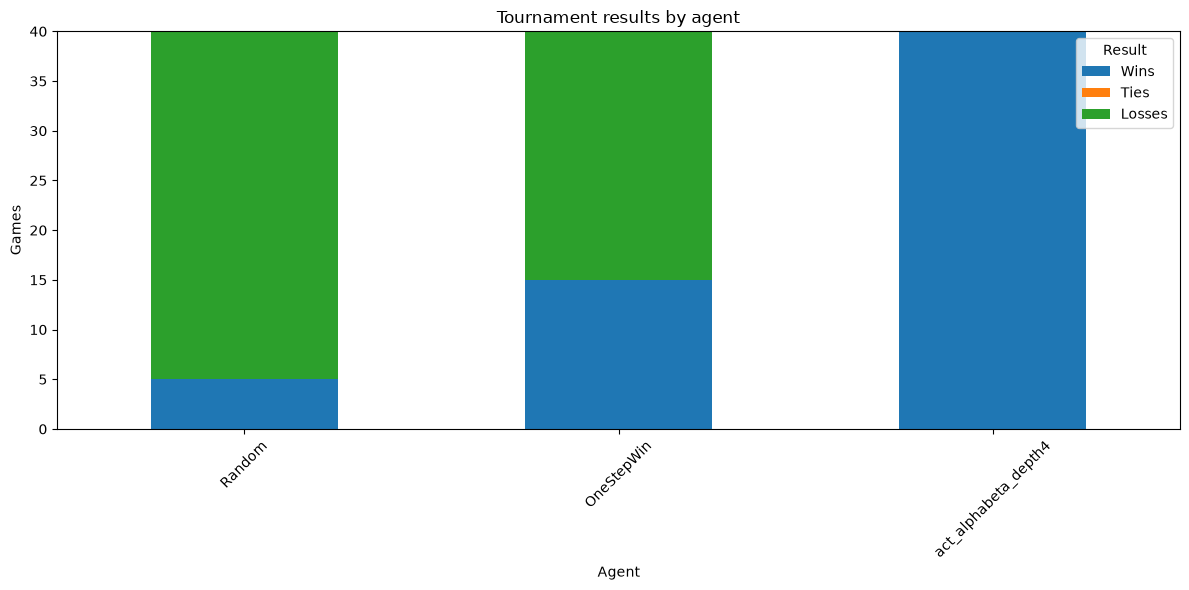

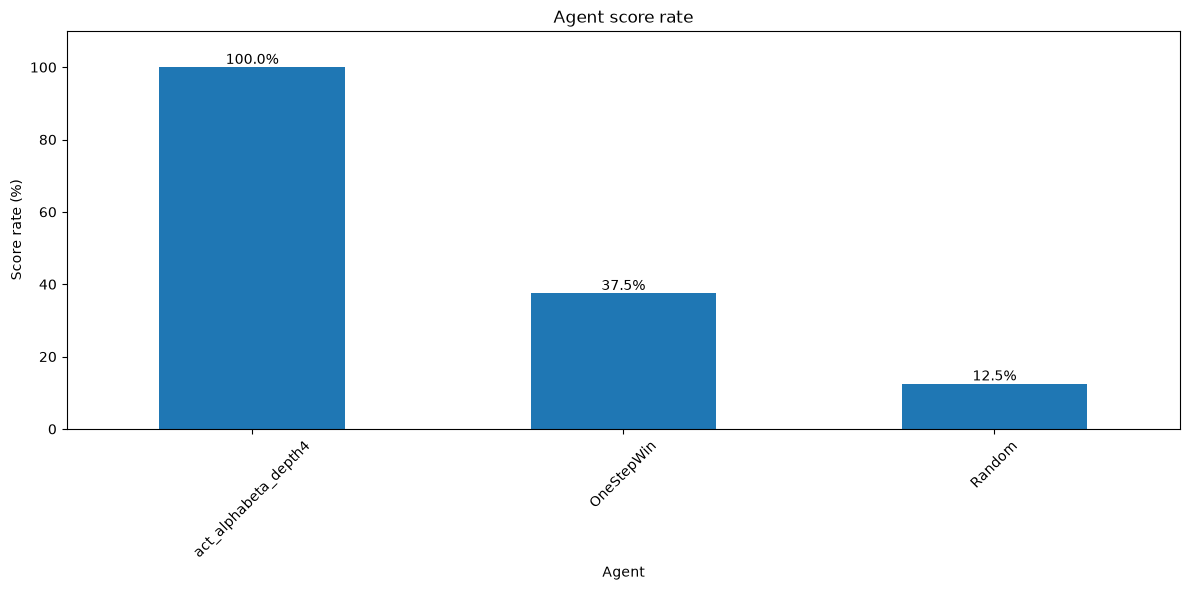

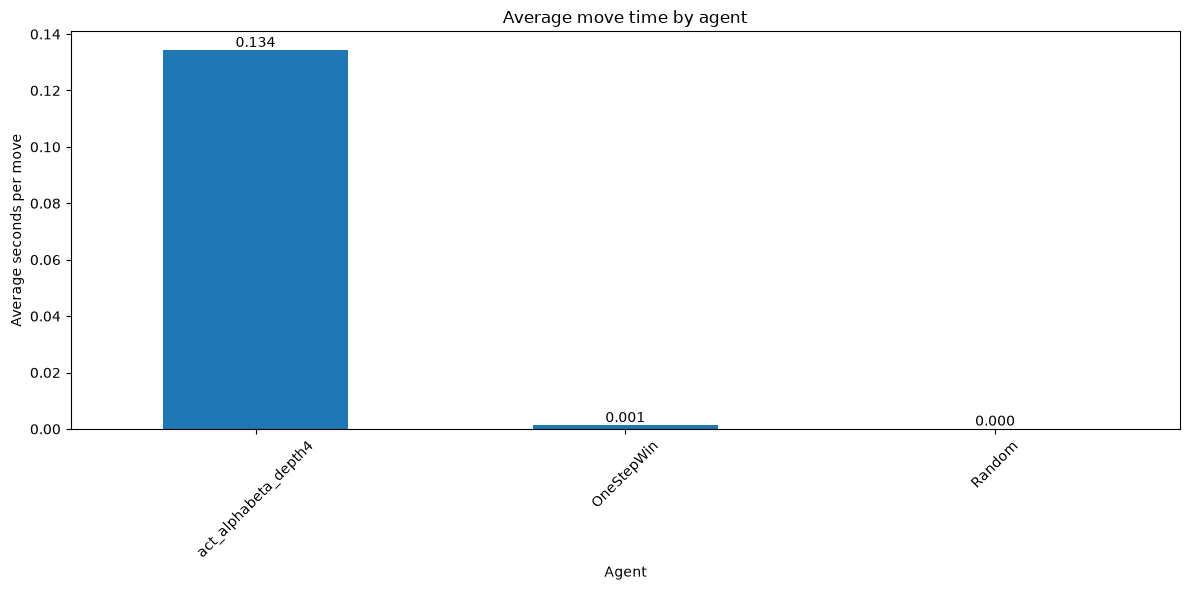

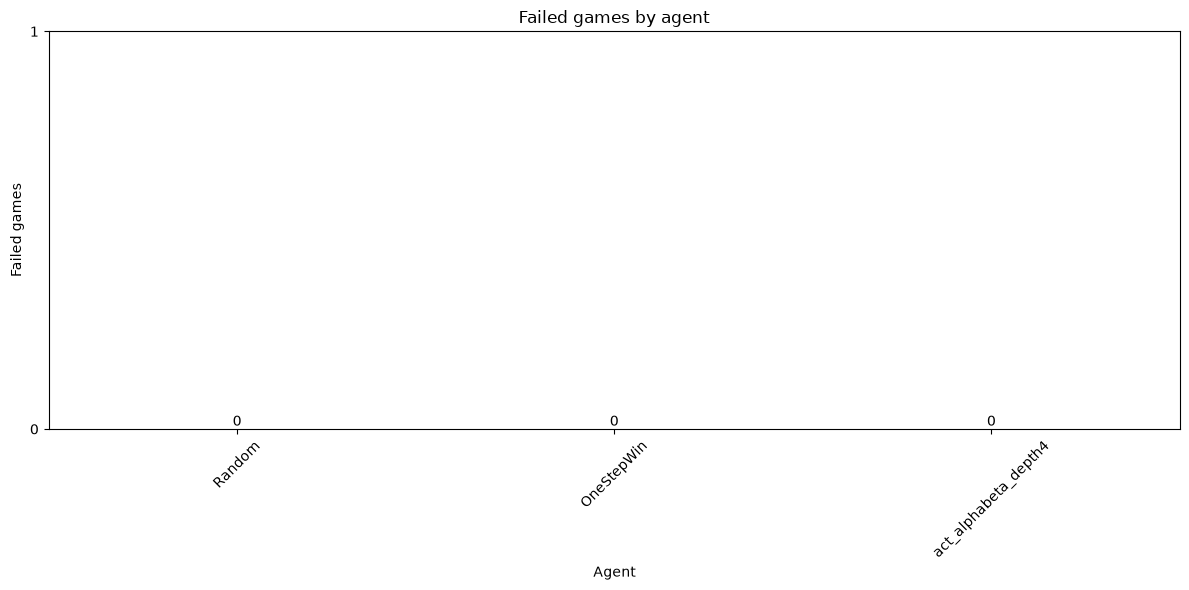

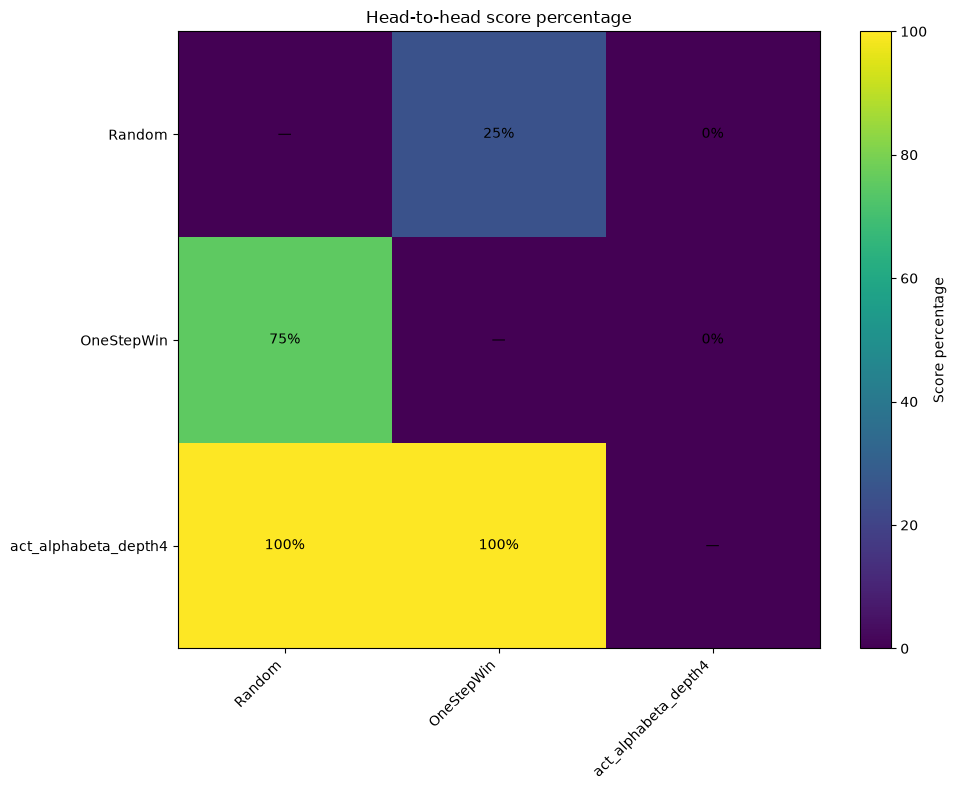

In [19]:
plot_agent_results(
    summary_df,
    head_to_head_df,
)

We can see that the depth-4 alpha-beta agent performs much better than its predecessors, but it also takes considerably longer to select each move. Let us compare the depth-4 agent with a depth-6 agent.

In [20]:
def act_alphabeta_depth6(
    observation,
    configuration,
):
    """
    Alpha-beta agent.

    Depth:
        6 plies

    Static evaluation:
        evaluate_board_static
    """
    return choose_alphabeta_move(
        observation=observation,
        configuration=configuration,
        search_depth=6,
        evaluation_function=evaluate_board_static,
        random_tiebreak=False,
    )

In [21]:
agents = [
    ("act_alphabeta_depth4", act_alphabeta_depth4),
    ("act_alphabeta_depth6", act_alphabeta_depth6)
]

head_to_head_df, summary_df, runtime_seconds, df_moves = evaluate_agents(
    agents=agents,
    games_per_matchup=10,
    starting_seed=42,
)



act_alphabeta_depth4 versus act_alphabeta_depth6
  Tournament game 1/10: Tie (started: act_alphabeta_depth4)
  Tournament game 2/10: Tie (started: act_alphabeta_depth6)
  Tournament game 3/10: Tie (started: act_alphabeta_depth4)
  Tournament game 4/10: Tie (started: act_alphabeta_depth6)
  Tournament game 5/10: Tie (started: act_alphabeta_depth4)
  Tournament game 6/10: Tie (started: act_alphabeta_depth6)
  Tournament game 7/10: Tie (started: act_alphabeta_depth4)
  Tournament game 8/10: Tie (started: act_alphabeta_depth6)
  Tournament game 9/10: Tie (started: act_alphabeta_depth4)
  Tournament game 10/10: Tie (started: act_alphabeta_depth6)

Total tournament time: 122.66 seconds


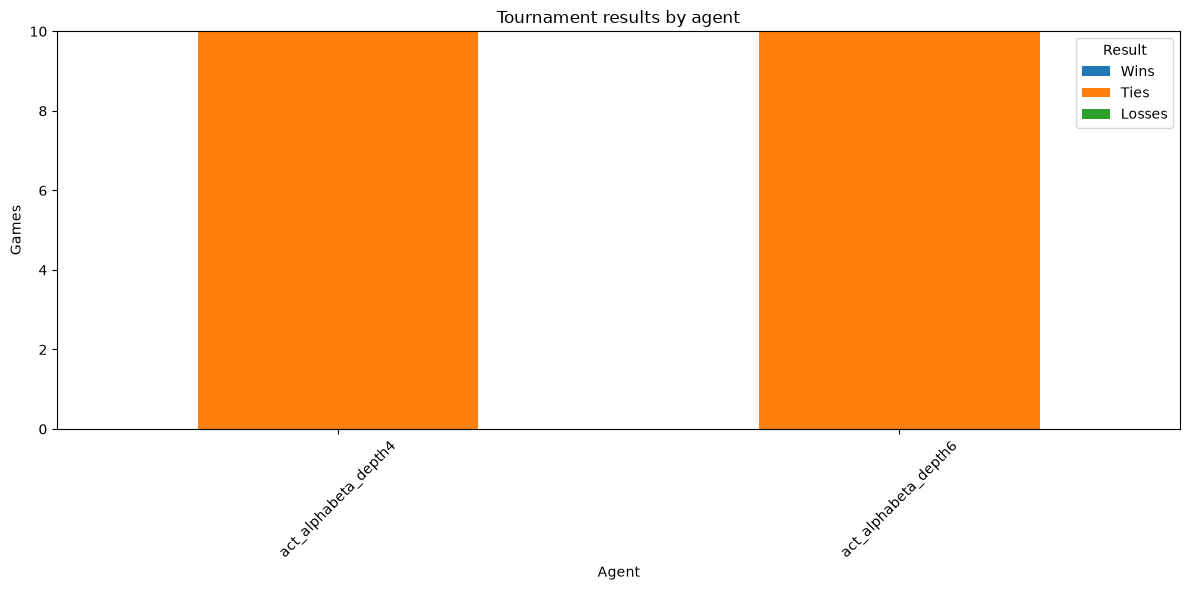

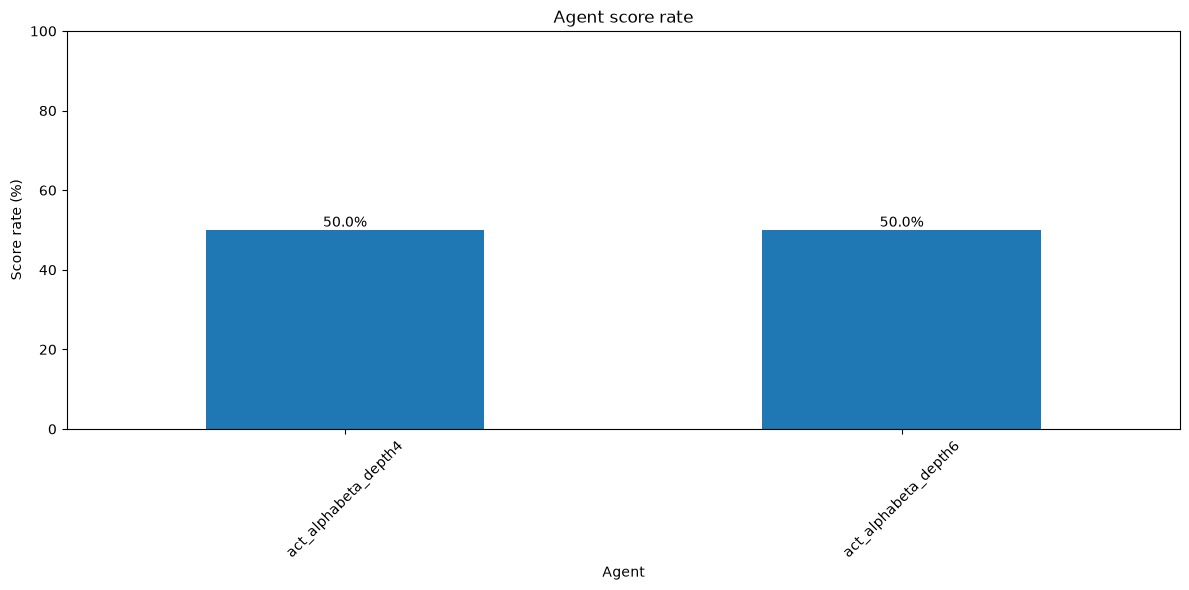

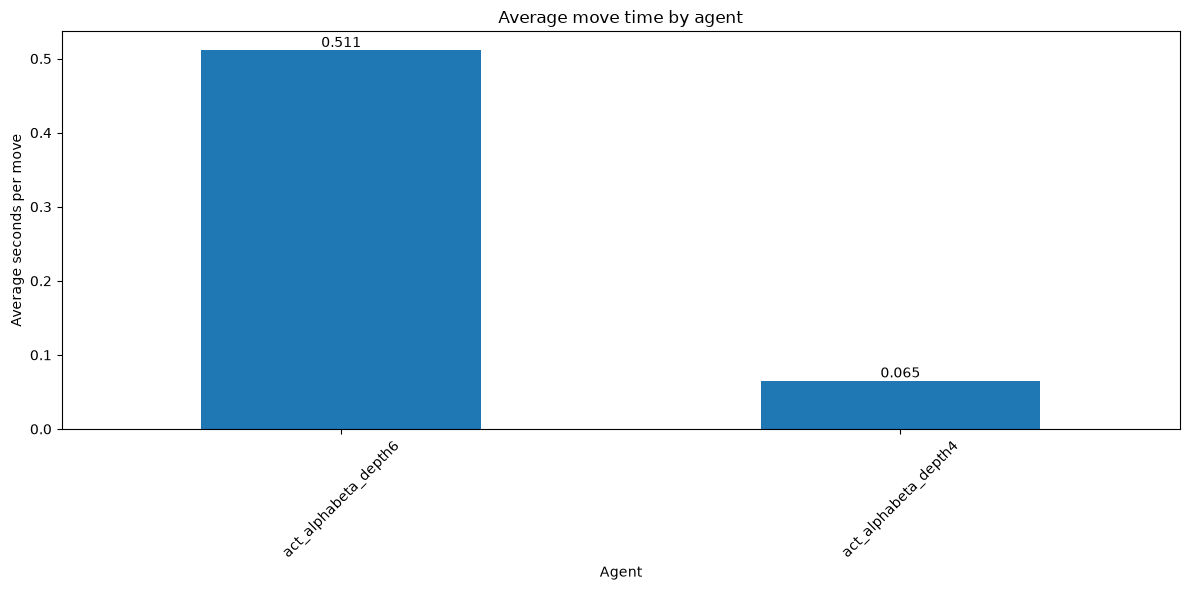

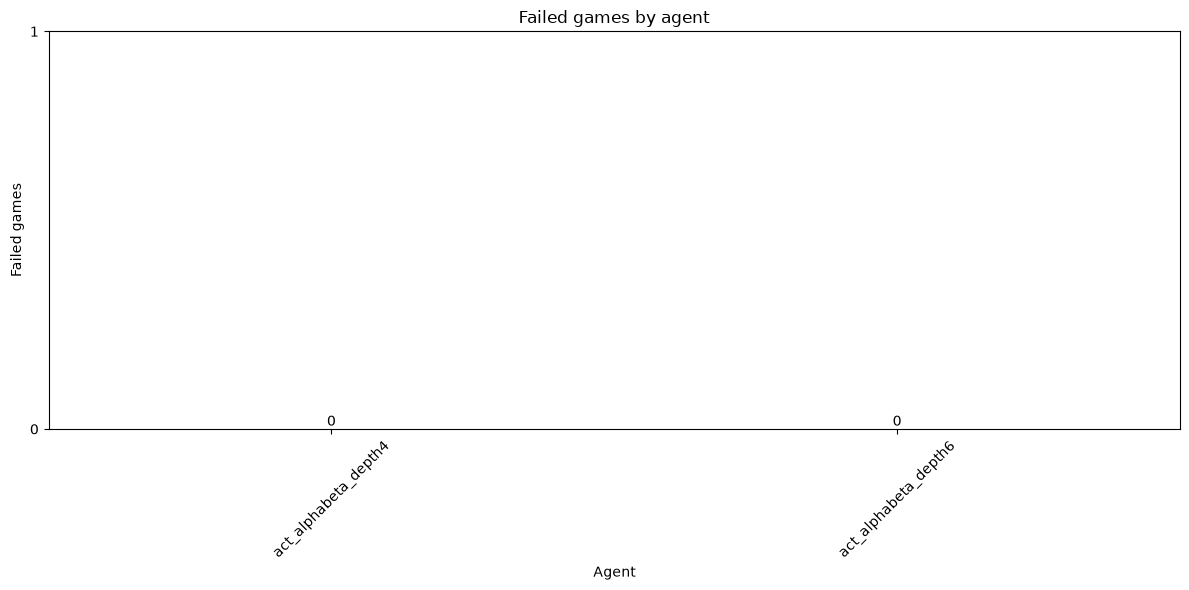

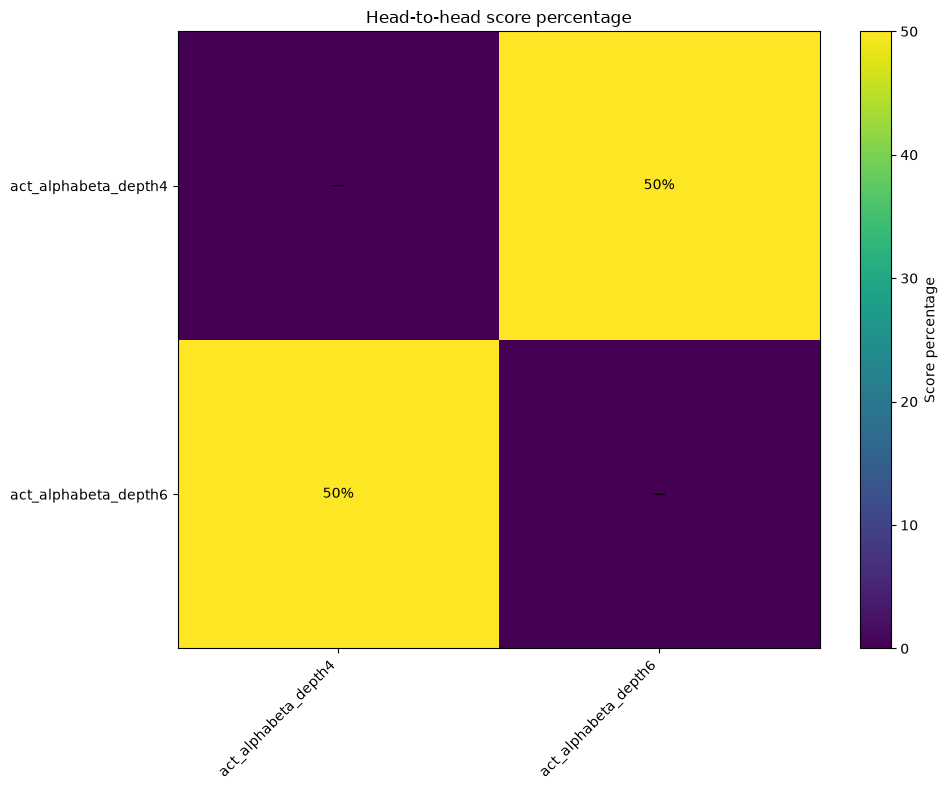

In [22]:

plot_agent_results(
    summary_df,
    head_to_head_df,
)

As expected, searching 6 moves ahead performs better than searching 4 moves ahead. However, we can also see that each move now takes approximately 0.5 seconds on average.

Increasing the search depth further would likely cause the agent to exceed Kaggle's 2-second time limit per move, resulting in forfeited games. This suggests that a search depth of 6 provides the best balance between playing strength and computational cost, making it a sensible choice for our agent.

## Static Evaluation Function

Let us now review the static evaluation function. We can improve it by incorporating heuristics that represent strategically strong positions.

One important constraint is that the static evaluation function should not look ahead to future moves. If it does, it begins to duplicate the role of the minimax search.

Possible heuristics include:

* Three pieces in a row with an adjacent empty space.
* Three pieces in a row where the adjacent empty space is supported by a piece underneath it.
* The equivalent patterns for two pieces in a row.
* A weighting for controlling the centre columns, which are often more strategically valuable.
* Negative scores when the opponent has any of these favourable patterns.

With these ideas in mind, let us define a function called `evaluate_board_column_weighted`. This function will identify each of these patterns and assign them an appropriate point weighting.



In [23]:
DEFAULT_EVALUATION_WEIGHTS = {
    "column_weights": None,
    "win_score": 1_000_000,
    "three_open": 100,
    "three_playable": 500,
    "two_open": 10,
    "two_playable": 50,
}


def normalise_evaluation_weights(weights, columns):
    """
    Return a complete dictionary of evaluation weights.

    Accepted formats
    ----------------
    None:
        Uses all default values.

    Dictionary:
        Allows selected values to be overridden.

        Example:
            {
                "column_weights": [3, 4, 5, 6, 5, 4, 3],
                "win_score": 1_000_000,
                "three_open": 100,
                "three_playable": 500,
                "two_open": 10,
                "two_playable": 50,
            }

    List or tuple:
        Interpreted in this order:

            [
                column_multiplier,
                two_open,
                two_playable,
                three_open,
                three_playable,
            ]

        Example:
            [1, 10, 50, 100, 500]
    """
    result = DEFAULT_EVALUATION_WEIGHTS.copy()

    if weights is None:
        pass

    elif isinstance(weights, dict):
        unknown_keys = set(weights) - set(result)

        if unknown_keys:
            raise ValueError(
                f"Unknown evaluation weight keys: {unknown_keys}"
            )

        result.update(weights)

    elif isinstance(weights, (list, tuple)):
        if len(weights) != 5:
            raise ValueError(
                "List-based weights must contain exactly five values: "
                "[column_multiplier, two_open, two_playable, "
                "three_open, three_playable]."
            )

        (
            column_multiplier,
            two_open,
            two_playable,
            three_open,
            three_playable,
        ) = weights

        result.update({
            "column_weights": make_column_weights(
                columns=columns,
                multiplier=column_multiplier,
            ),
            "two_open": two_open,
            "two_playable": two_playable,
            "three_open": three_open,
            "three_playable": three_playable,
        })

    else:
        raise TypeError(
            "weights must be None, a dictionary, list, or tuple."
        )

    if result["column_weights"] is None:
        result["column_weights"] = make_column_weights(
            columns=columns,
            multiplier=1,
        )

    if len(result["column_weights"]) != columns:
        raise ValueError(
            "The number of column weights must equal "
            f"configuration.columns ({columns})."
        )

    return result


def make_column_weights(columns, multiplier=1):
    """
    Create symmetric column weights that favour central columns.

    For seven columns and multiplier=1, this produces:

        [1, 2, 3, 4, 3, 2, 1]

    To reproduce approximately the original weighting, supply the
    column weights directly in the weights dictionary.
    """
    centre = (columns - 1) / 2

    raw_weights = [
        columns - abs(column - centre)
        for column in range(columns)
    ]

    minimum = min(raw_weights)

    return [
        multiplier * int(round(value - minimum + 1))
        for value in raw_weights
    ]


def is_playable_gap(
    board,
    row,
    column,
    rows,
    columns,
):
    """
    Return True when a piece could legally be dropped into this
    empty cell on the next move.
    """
    index = row * columns + column

    if board[index] != 0:
        return False

    if row == rows - 1:
        return True

    below_index = (row + 1) * columns + column
    return board[below_index] != 0


def get_scoring_lines(rows, columns, inarow):
    """
    Return every complete row, column, and diagonal that is long
    enough to contain a winning sequence.

    Each line is represented as a tuple of (row, column) pairs.
    """
    lines = []

    # Horizontal lines
    for row in range(rows):
        line = tuple(
            (row, column)
            for column in range(columns)
        )

        if len(line) >= inarow:
            lines.append(line)

    # Vertical lines
    for column in range(columns):
        line = tuple(
            (row, column)
            for row in range(rows)
        )

        if len(line) >= inarow:
            lines.append(line)

    # Down-right diagonals starting from the top row
    for start_column in range(columns):
        diagonal = []

        row = 0
        column = start_column

        while row < rows and column < columns:
            diagonal.append((row, column))
            row += 1
            column += 1

        if len(diagonal) >= inarow:
            lines.append(tuple(diagonal))

    # Down-right diagonals starting from the left edge
    for start_row in range(1, rows):
        diagonal = []

        row = start_row
        column = 0

        while row < rows and column < columns:
            diagonal.append((row, column))
            row += 1
            column += 1

        if len(diagonal) >= inarow:
            lines.append(tuple(diagonal))

    # Up-right diagonals starting from the bottom row
    for start_column in range(columns):
        diagonal = []

        row = rows - 1
        column = start_column

        while row >= 0 and column < columns:
            diagonal.append((row, column))
            row -= 1
            column += 1

        if len(diagonal) >= inarow:
            lines.append(tuple(diagonal))

    # Up-right diagonals starting from the left edge
    for start_row in range(rows - 2, -1, -1):
        diagonal = []

        row = start_row
        column = 0

        while row >= 0 and column < columns:
            diagonal.append((row, column))
            row -= 1
            column += 1

        if len(diagonal) >= inarow:
            lines.append(tuple(diagonal))

    return tuple(lines)


def score_open_end(
    board,
    row,
    column,
    rows,
    columns,
    open_score,
    playable_score,
):
    """
    Score one empty cell adjacent to a contiguous run.
    """
    index = row * columns + column

    if board[index] != 0:
        return 0

    if is_playable_gap(
        board=board,
        row=row,
        column=column,
        rows=rows,
        columns=columns,
    ):
        return playable_score

    return open_score


def score_runs_for_player(
    board,
    player,
    rows,
    columns,
    inarow,
    scoring_lines,
    weights,
):
    """
    Score contiguous runs belonging to one player.

    This implementation assumes Connect Four-style scoring for
    runs of length two and three. It remains configurable for board
    dimensions, but is primarily intended for inarow=4.
    """
    score = 0

    for line in scoring_lines:
        values = [
            board[row * columns + column]
            for row, column in line
        ]

        position = 0

        while position < len(values):
            if values[position] != player:
                position += 1
                continue

            run_start = position

            while (
                position < len(values)
                and values[position] == player
            ):
                position += 1

            run_end = position - 1
            run_length = run_end - run_start + 1

            if run_length == inarow - 1:
                open_score = weights["three_open"]
                playable_score = weights["three_playable"]

            elif run_length == inarow - 2:
                open_score = weights["two_open"]
                playable_score = weights["two_playable"]

            else:
                continue

            before_index = run_start - 1

            if before_index >= 0:
                row, column = line[before_index]

                score += score_open_end(
                    board=board,
                    row=row,
                    column=column,
                    rows=rows,
                    columns=columns,
                    open_score=open_score,
                    playable_score=playable_score,
                )

            after_index = run_end + 1

            if after_index < len(line):
                row, column = line[after_index]

                score += score_open_end(
                    board=board,
                    row=row,
                    column=column,
                    rows=rows,
                    columns=columns,
                    open_score=open_score,
                    playable_score=playable_score,
                )

    return score


def evaluate_board_column_weighted(
    board,
    mark,
    configuration,
    weights=None,
):
    """
    Evaluate the board from the perspective of mark.

    Parameters
    ----------
    board:
        Flat ConnectX board.

    mark:
        Player being evaluated, normally 1 or 2.

    configuration:
        Kaggle ConnectX configuration containing:
            rows
            columns
            inarow

    weights:
        None, dictionary, list, or tuple.

    Dictionary example
    ------------------
    {
        "column_weights": [3, 4, 5, 6, 5, 4, 3],
        "win_score": 1_000_000,
        "three_open": 100,
        "three_playable": 500,
        "two_open": 10,
        "two_playable": 50,
    }

    List example
    ------------
    [
        1,      # automatic column-weight multiplier
        10,     # two_open
        50,     # two_playable
        100,    # three_open
        500,    # three_playable
    ]
    """
    rows = configuration.rows
    columns = configuration.columns
    inarow = configuration.inarow

    expected_board_size = rows * columns

    if len(board) != expected_board_size:
        raise ValueError(
            f"Board contains {len(board)} cells, but configuration "
            f"requires {expected_board_size}."
        )

    weights = normalise_evaluation_weights(
        weights=weights,
        columns=columns,
    )

    opponent = 1 if mark == 2 else 2

    # Assumes winning_move supports configuration. If your current
    # winning_move only accepts board and mark, adjust this call to
    # match its existing signature.
    if winning_move(
        board,
        mark,
    ):
        return weights["win_score"]

    if winning_move(
        board,
        opponent,
    ):
        return -weights["win_score"]

    score = 0
    column_weights = weights["column_weights"]

    # Positional value of placed pieces.
    for row in range(rows):
        for column in range(columns):
            cell = board[row * columns + column]
            position_score = column_weights[column]

            if cell == mark:
                score += position_score

            elif cell == opponent:
                score -= position_score

    scoring_lines = get_scoring_lines(
        rows=rows,
        columns=columns,
        inarow=inarow,
    )

    score += score_runs_for_player(
        board=board,
        player=mark,
        rows=rows,
        columns=columns,
        inarow=inarow,
        scoring_lines=scoring_lines,
        weights=weights,
    )

    score -= score_runs_for_player(
        board=board,
        player=opponent,
        rows=rows,
        columns=columns,
        inarow=inarow,
        scoring_lines=scoring_lines,
        weights=weights,
    )

    return score

We can compare two agents using the same search depth but different evaluation weightings to determine whether the new heuristics improve playing strength or significantly affect the average move time.

To speed up experimentation, we can perform these comparisons using a lower search depth, allowing us to evaluate many more games in a reasonable amount of time. Once we have identified the best-performing set of weightings, we can apply them to the higher-depth agent that will ultimately be submitted to the Kaggle competition.


In [24]:
WEIGHTS_1 = {
    "column_weights": [3, 4, 5, 6, 5, 4, 3],
    "win_score": 1_000_000,
    "three_open": 100,
    "three_playable": 500,
    "two_open": 10,
    "two_playable": 50,
}

def act_alphabeta_depth1_weighted1(
    observation,
    configuration,
):
    """
    Alpha-beta agent.

    Depth:
        6 plies

    Static evaluation:
        evaluate_board_static
    """
    return choose_alphabeta_move(
        observation=observation,
        configuration=configuration,
        search_depth=1,
        evaluation_function=evaluate_board_column_weighted,
        evaluation_weights=WEIGHTS_1,
        random_tiebreak=False,
    )


WEIGHTS_2 = {
    "column_weights": None,
    "win_score": 1_000_000,
    "three_open": 100,
    "three_playable": 0,
    "two_open": 10,
    "two_playable": 0,
}


def act_alphabeta_depth1_weighted2(
    observation,
    configuration,
):
    """
    Alpha-beta agent.

    Depth:
        6 plies

    Static evaluation:
        evaluate_board_static
    """
    return choose_alphabeta_move(
        observation=observation,
        configuration=configuration,
        search_depth=1,
        evaluation_function=evaluate_board_column_weighted,
        evaluation_weights=WEIGHTS_2,
        random_tiebreak=False,
    )

WEIGHTS_3 = {
    "column_weights": None,
    "win_score": 1_000_000,
    "three_open": 0,
    "three_playable": 0,
    "two_open": 0,
    "two_playable": 0,
}


def act_alphabeta_depth1_weighted3(
    observation,
    configuration,
):
    """
    Alpha-beta agent.

    Depth:
        6 plies

    Static evaluation:
        evaluate_board_static
    """
    return choose_alphabeta_move(
        observation=observation,
        configuration=configuration,
        search_depth=1,
        evaluation_function=evaluate_board_column_weighted,
        evaluation_weights=WEIGHTS_3,
        random_tiebreak=False,
    )

WEIGHTS_4 = {
    "column_weights": [3, 4, 5, 6, 5, 4, 3],
    "win_score": 1_000_000,
    "three_open": 20,
    "three_playable": 0,
    "two_open": 5,
    "two_playable": 0,
}


def act_alphabeta_depth1_weighted4(
    observation,
    configuration,
):
    """
    Alpha-beta agent.

    Depth:
        6 plies

    Static evaluation:
        evaluate_board_static
    """
    return choose_alphabeta_move(
        observation=observation,
        configuration=configuration,
        search_depth=1,
        evaluation_function=evaluate_board_column_weighted,
        evaluation_weights=WEIGHTS_4,
        random_tiebreak=False,
    )

In [25]:

    agents = [
        ("act_alphabeta_depth1_weighted1", act_alphabeta_depth1_weighted1),
        ("act_alphabeta_depth1_weighted2", act_alphabeta_depth1_weighted2),
        ("act_alphabeta_depth1_weighted3", act_alphabeta_depth1_weighted3),
        ("act_alphabeta_depth1_weighted4", act_alphabeta_depth1_weighted4),
    ]
    
    head_to_head_df, summary_df, runtime_seconds, df_moves = evaluate_agents(
        agents=agents,
        games_per_matchup=100,
        starting_seed=42,
        random_start=True,
    )
    



act_alphabeta_depth1_weighted1 versus act_alphabeta_depth1_weighted2
  Tournament game 1/600: act_alphabeta_depth1_weighted1 wins (started: act_alphabeta_depth1_weighted1, random opening: 2 moves)
  Tournament game 2/600: act_alphabeta_depth1_weighted2 wins (started: act_alphabeta_depth1_weighted2, random opening: 4 moves)
  Tournament game 3/600: act_alphabeta_depth1_weighted2 wins (started: act_alphabeta_depth1_weighted1, random opening: 4 moves)
  Tournament game 4/600: act_alphabeta_depth1_weighted1 wins (started: act_alphabeta_depth1_weighted2, random opening: 4 moves)
  Tournament game 5/600: act_alphabeta_depth1_weighted2 wins (started: act_alphabeta_depth1_weighted1, random opening: 2 moves)
  Tournament game 6/600: act_alphabeta_depth1_weighted1 wins (started: act_alphabeta_depth1_weighted2, random opening: 4 moves)
  Tournament game 7/600: act_alphabeta_depth1_weighted1 wins (started: act_alphabeta_depth1_weighted1, random opening: 2 moves)
  Tournament game 8/600: act_alpha

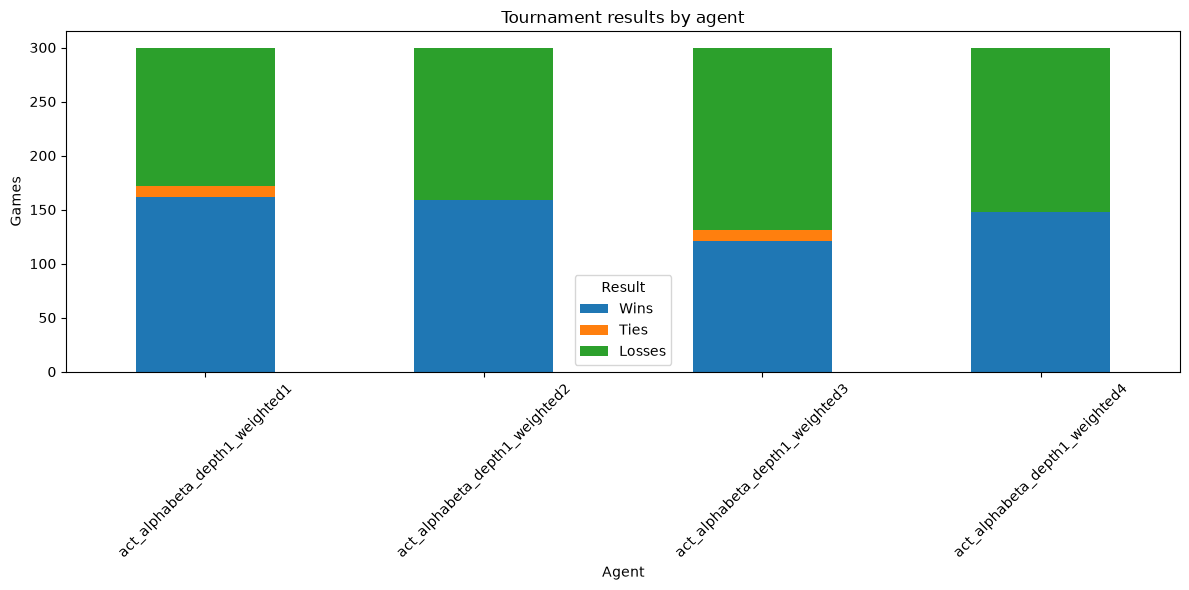

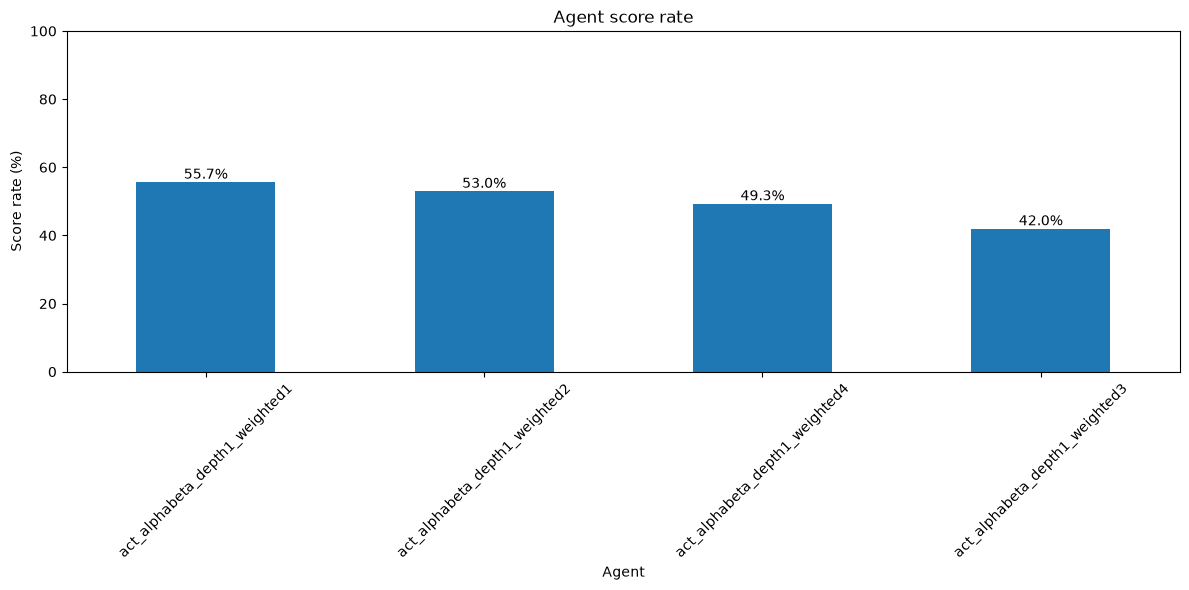

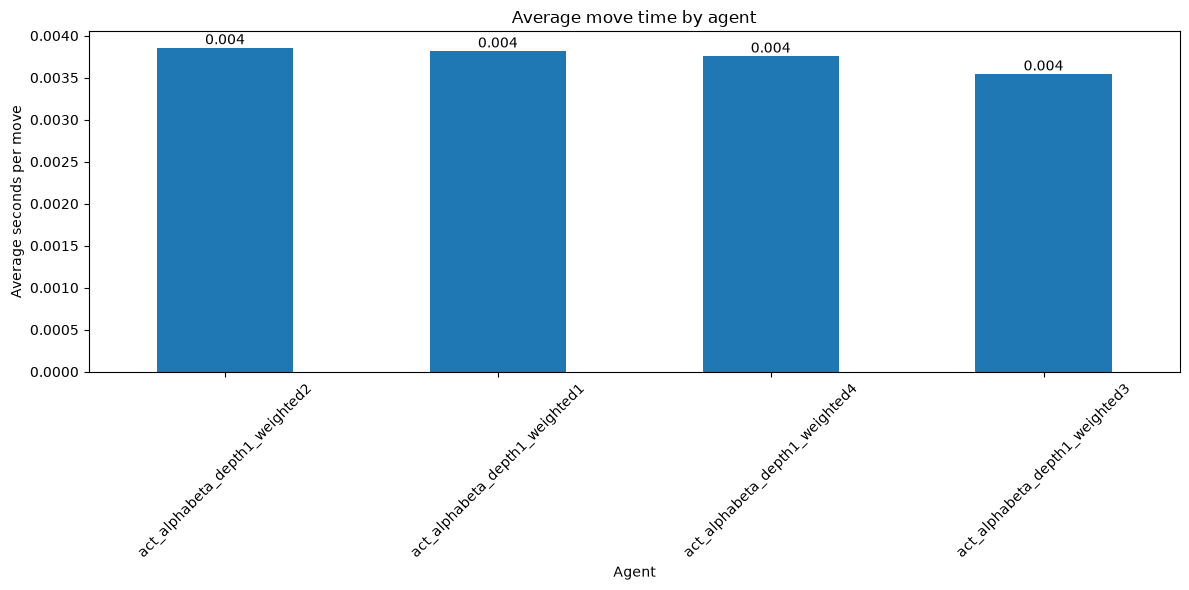

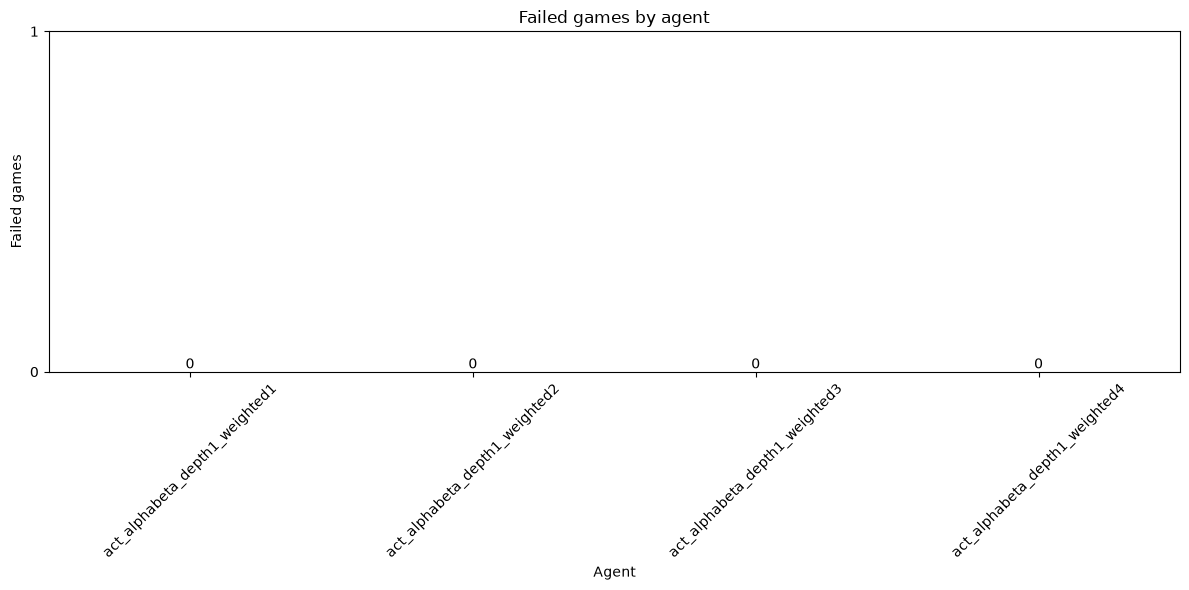

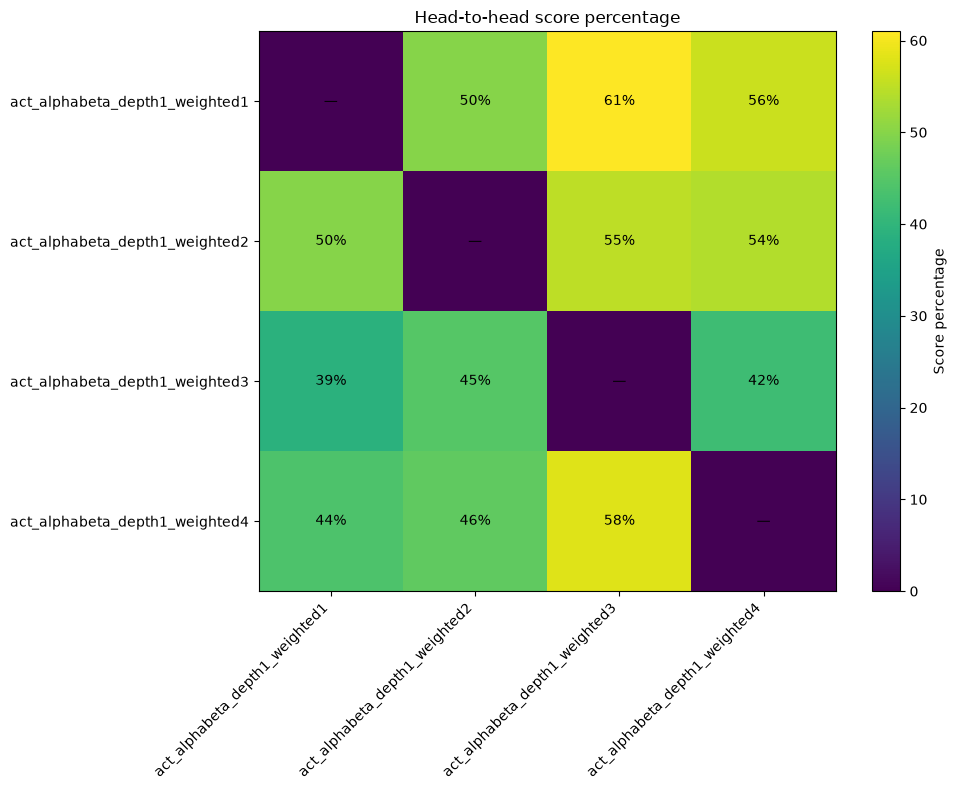

In [27]:
    plot_agent_results(
        summary_df,
        head_to_head_df,)

## Submission

There is no substantial difference between the weighting configurations, but the first performs best overall. We will therefore use this weighting together with a search depth of 6 for our final submission.

To submit the agent to Kaggle, we need to include the winning agent and all of its supporting functions.

We must also remember to rename the main agent function to act, as this is the function name the competition expects.

After submission, the agent achieves an Elo rating of approximately 630, which is a significant improvement over our earlier results.

Let us finish by demonstrating a game played by our final agent.

In [28]:
env = make("connectx", debug=True)
env.run([act_alphabeta_depth1_weighted1, "random"])
env.render(mode="ipython")

## Future Work

There are several ways this agent could be improved further.

First, we could add additional heuristics to the static evaluation function to better capture what constitutes a strong board position. These heuristics could then be assigned weightings that are tuned to maximise playing strength.

Rather than selecting these weightings manually, we could use an optimisation technique, such as a genetic algorithm, to automatically search for an effective combination of weights.

Finally, improving the efficiency of the minimax implementation would allow the agent to search to greater depths within Kaggle's 2-second time limit. A deeper search would generally lead to stronger play and, consequently, a higher Elo rating.